In [5]:
%load_ext autoreload
%autoreload 2

### 1. 모듈 임포트

In [6]:
import torch
import numpy as np
# 1. 모듈 임포트
from modules.config import config
from modules.sdf_generator import SDFGenerator
from modules.particle_sampler import sample_particles_poisson
from modules.sdf_network import FeatureConstruction
from modules.visualizer import visualize_simulation, visualize_particles_and_features, visualize_feature_grid

In [7]:
# ==========================================
# Setup: Config & 디바이스 초기화
# ==========================================
print(f"⚙️ Config 설정: Domain Size={config.domain_size}, Resolution={config.resolution}")
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"⚡ 디바이스 초기화: {device}")

⚙️ Config 설정: Domain Size=2.0, Resolution=128
⚡ 디바이스 초기화: cuda


## 2. 데이터셋 생성

### 2.1 데이터 셋 sdf 생성 및 Poisson Disk 샘플링

In [84]:
import os
import glob
from modules.dataset import SDFDataset

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# sdf, 파티클 생성 함수.
SDFDataset.generate_dataset(
    output_dir="dataset6",
    dataset_size=200,
    start_index=0,
    save_sdf=True,
    save_particles=True,
    save_mc=True,        # mc는 데이터로더에서도 계산 가능. False해도 됨.
    config=config,
    device=device,
    cleanup_old_files = True
)

🗑️ Removed old dataset file: dataset6\mc_grid_000.npy
🗑️ Removed old dataset file: dataset6\mc_grid_001.npy
🗑️ Removed old dataset file: dataset6\mc_grid_002.npy
🗑️ Removed old dataset file: dataset6\mc_grid_003.npy
🗑️ Removed old dataset file: dataset6\mc_grid_004.npy
🗑️ Removed old dataset file: dataset6\mc_grid_005.npy
🗑️ Removed old dataset file: dataset6\mc_grid_006.npy
🗑️ Removed old dataset file: dataset6\mc_grid_007.npy
🗑️ Removed old dataset file: dataset6\mc_grid_008.npy
🗑️ Removed old dataset file: dataset6\mc_grid_009.npy
🗑️ Removed old dataset file: dataset6\mc_grid_010.npy
🗑️ Removed old dataset file: dataset6\mc_grid_011.npy
🗑️ Removed old dataset file: dataset6\mc_grid_012.npy
🗑️ Removed old dataset file: dataset6\mc_grid_013.npy
🗑️ Removed old dataset file: dataset6\mc_grid_014.npy
🗑️ Removed old dataset file: dataset6\mc_grid_015.npy
🗑️ Removed old dataset file: dataset6\mc_grid_016.npy
🗑️ Removed old dataset file: dataset6\mc_grid_017.npy
🗑️ Removed old dataset file:

KeyboardInterrupt: 

In [319]:
# ==========================================
# 1. 모듈 임포트 및 Taichi 엔진 초기화
# ==========================================
import taichi as ti
from modules.config import config
from modules.taichi_fluid_solver  import TaichiFluidSolver

# 🚨 시각화나 솔버를 초기화하기 전에 반드시 GPU(혹은 CPU) 런타임을 먼저 켭니다.
ti.init(arch=ti.gpu)


# (visualizer.py가 같은 경로에 있다면 바로 임포트, modules 폴더 안이라면 modules.visualizer로 임포트)
from modules.visualizer import run_realtime_visualizer 

# ==========================================
# 2. 유체 시뮬레이터 세팅
# ==========================================
res = config.resolution            # 실시간 테스트용 해상도
domain_size = config.domain_size

# 솔버 객체 생성 및 초기 물기둥(Dam Break) 배치
solver = TaichiFluidSolver(res=config.resolution, domain_size=config.domain_size, p_per_cell=1.0)
solver.setup_initial_fluid_block()

print(f"✅ 준비된 활성 파티클 수: {solver.get_active_particle_count():,}개")

# ==========================================
# 3. 실시간 3D 뷰어 구동!
# ==========================================
# 세팅이 끝난 솔버를 통째로 뷰어에 넘겨줍니다.
solver.run_taichi_viewer()

[Taichi] Starting on arch=cuda
✅ 준비된 활성 파티클 수: 156,832개

[초고속 튜닝 SPH 뷰어 구동]


In [324]:
import os
import glob
from modules.dataset import SDFDataset

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# sdf, 파티클 생성 함수.
TaichiFluidSolver.generate_dataset(
    output_dir="dataset4",
    dataset_size=200,
    start_index=0,
    save_sdf=True,
    save_particles=True,
    save_mc=True,        # mc는 데이터로더에서도 계산 가능. False해도 됨.
    config=config,
    device=device,
    cleanup_old_files = True
)

🗑️ Removed 75 old dataset files.
self.R : 0.03125

🚀 Launching Optimized Fluid Simulator Pipeline...
   [Target Frames]: 200 | Resolution: 128^3

[1/200] Simulating Fluid State...
   💾 [Frame 000] Extracting & Saving Data...
   ✅ Saved Frame 000: SDF, Particles, m_c Grid (Particles: 156,832)

[2/200] Simulating Fluid State...
   ⏩ Pass saving (Physics updated)

[3/200] Simulating Fluid State...
   ⏩ Pass saving (Physics updated)

[4/200] Simulating Fluid State...
   ⏩ Pass saving (Physics updated)

[5/200] Simulating Fluid State...
   💾 [Frame 004] Extracting & Saving Data...
   ✅ Saved Frame 004: SDF, Particles, m_c Grid (Particles: 156,832)

[6/200] Simulating Fluid State...
   ⏩ Pass saving (Physics updated)

[7/200] Simulating Fluid State...
   ⏩ Pass saving (Physics updated)

[8/200] Simulating Fluid State...
   ⏩ Pass saving (Physics updated)

[9/200] Simulating Fluid State...
   💾 [Frame 008] Extracting & Saving Data...
   ✅ Saved Frame 008: SDF, Particles, m_c Grid (Particles: 

In [224]:
# 1. 기존 Config 설정값 기준
domain_size = config.domain_size
resolution = config.resolution
node_resolution = resolution + 1

min_bound = -domain_size / 2.0  # -1.0
max_bound = domain_size / 2.0   # 1.0

# 2. X, Y, Z 축 각각에 대해 -1.0 부터 1.0 까지 64등분한 좌표점 생성
axis_coords = torch.linspace(min_bound, max_bound, node_resolution)

# 3. 3차원 공간(Meshgrid)으로 확장하여 (64, 64, 64, 3) 형태의 텐서 생성
X, Y, Z = torch.meshgrid(axis_coords, axis_coords, axis_coords, indexing='ij')

# 4. 좌표들을 하나로 묶고 (262144, 3) 형태로 평탄화(Flatten)
grid_nodes = torch.stack([X, Y, Z], dim=-1).reshape(-1, 3)

print(f"✅ 복구된 grid_nodes 형태: {grid_nodes.shape}")

✅ 복구된 grid_nodes 형태: torch.Size([2146689, 3])


### visualize dataset

📥 SDF 데이터 로드: dataset6/sdf_grid_150.npy (Shape: (128, 128, 128))
📥 m_c 데이터 로드: dataset6/mc_grid_150.npy (Shape: (129, 129, 129))

[1] 정답(Target) SDF 형상 시각화


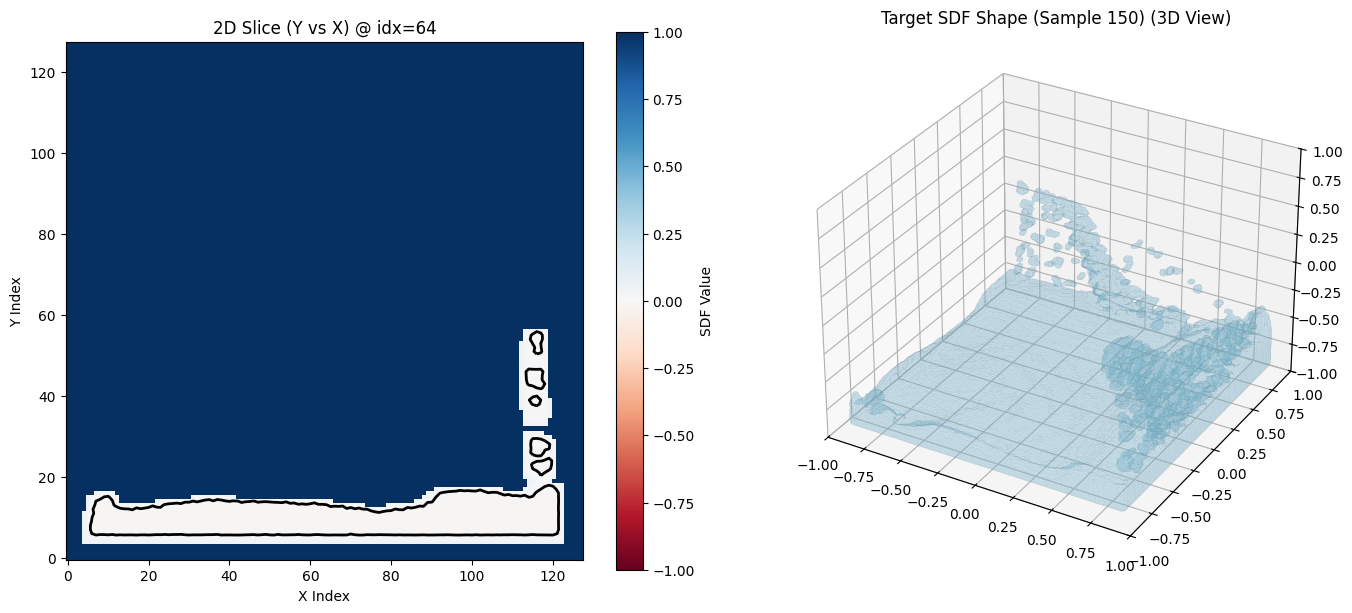


[2] 입력(Input) m_c 특징 공간 시각화


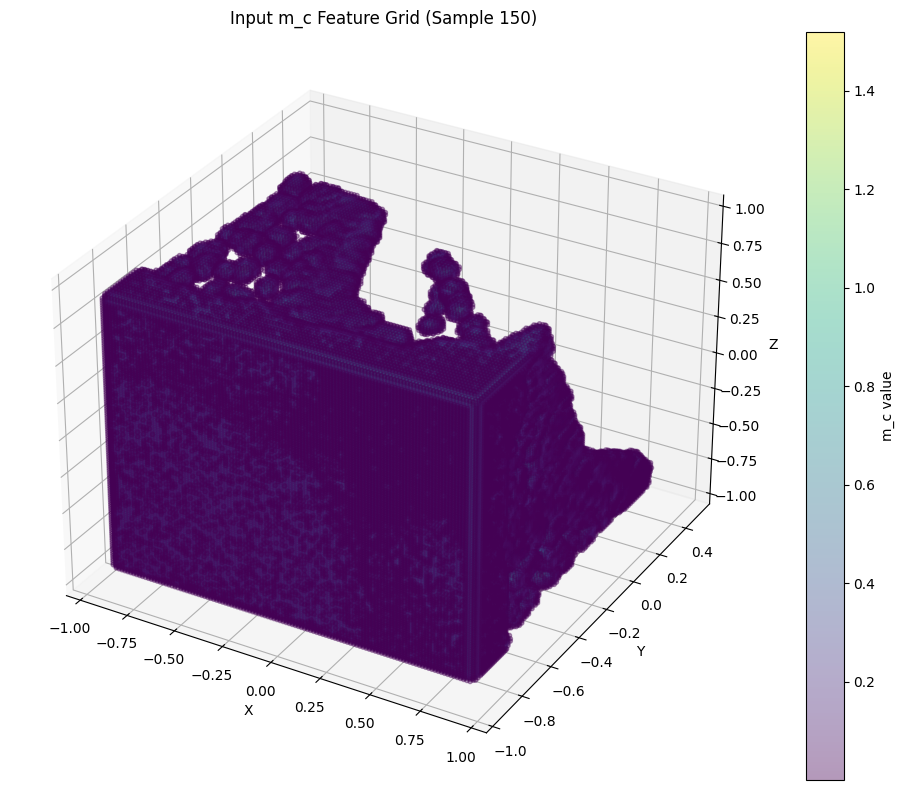

In [236]:
import numpy as np
import torch
from modules.config import config
from modules.visualizer import visualize_simulation, visualize_feature_grid,visualize_particles_and_features

# 1. 확인할 데이터 인덱스 설정 (0 ~ 4)
sample_idx = 150
sdf_file = f"dataset6/sdf_grid_{sample_idx:03d}.npy"
mc_file = f"dataset6/mc_grid_{sample_idx:03d}.npy"

# 2. 데이터 로드 완료
sdf_grid = np.load(sdf_file)
mc_grid = np.load(mc_file)
print(f"📥 SDF 데이터 로드: {sdf_file} (Shape: {sdf_grid.shape})")
print(f"📥 m_c 데이터 로드: {mc_file} (Shape: {mc_grid.shape})")

# 3. [시각화 1] Target SDF (원본 3D 지오메트리 형태)
print("\n[1] 정답(Target) SDF 형상 시각화")
visualize_simulation(
    sdf_grid=sdf_grid, 
    domain_size=config.domain_size, 
    title=f"Target SDF Shape (Sample {sample_idx})"
)

# 4. [시각화 2] Input 3D CNN Features (파티클로부터 밀도 단위로 추출된 m_c 값)
print("\n[2] 입력(Input) m_c 특징 공간 시각화")

fig2 = visualize_feature_grid(
    m_c_grid=mc_grid,         # 앞서 파이프라인에서 나온 mc_grid 텐서 그대로 삽입
    grid_nodes=grid_nodes,    # 앞서 파이프라인에서 나온 grid_nodes 텐서 그대로 삽입
    title=f"Input m_c Feature Grid (Sample {sample_idx})"
)

sdf to obj

In [ ]:
from modules.visualizer import save_mesh_as_obj, draw_sdf_mesh, view_obj_interactive

# 1. 확인할 프레임 번호 및 기본 경로 설정
frame_number = 100  # 확인하고 싶은 프레임 번호 입력
dataset_dir = "dataset6"

# 앞서 데이터셋 생성 시 사용한 자릿수(03d)에 맞춰 파일명 지정
npy_path = os.path.join(dataset_dir, f"sdf_grid_{frame_number:03d}.npy")
obj_path = os.path.join(dataset_dir, f"frame_{frame_number:03d}.obj")

# 2. SDF 데이터 로드 및 처리
if not os.path.exists(npy_path):
    print(f"❌ 경고: 파일을 찾을 수 없습니다 ({npy_path})")
else:
    print(f"[{frame_number:03d} 프레임] SDF 데이터를 로드합니다...")
    sdf_grid = np.load(npy_path)

    # 3. visualizer.py의 함수를 호출하여 OBJ 파일로 추출 및 저장
    success = save_mesh_as_obj(sdf_grid, filename=obj_path, level=0.0)


[0100 프레임] SDF 데이터를 로드합니다...
✅ 메쉬 저장 완료: dataset6\frame_100.obj (Vertices: 94445)


In [90]:
import open3d as o3d
import os

frame_number = 100  # 확인하고 싶은 프레임 번호 입력
obj_path = os.path.join(dataset_dir, f"frame_{frame_number:03d}.obj")

# 4. OBJ 파일이 성공적으로 저장되었다면 뷰어 실행
view_obj_interactive(filename=obj_path)

🖥️ 3D 뷰어 실행 중: dataset6\frame_100.obj ...
✅ 뷰어 종료됨.


## 3. sdf 계산 -CNN 학습

### 3.1 전처리 단계: 그리드 특징값(m_c) 계산

### 3.2 m_c 값 시각화

SDF Input : 학습이나 추론용 

In [ ]:
import torch
import numpy as np
import os
# 1. 모듈 임포트
from modules.config import config
from modules.sdf_generator import SDFGenerator
from modules.particle_sampler import sample_particles_poisson
from modules.sdf_network import FeatureConstruction
from modules.visualizer import visualize_simulation, visualize_particles_and_features

# ==========================================
# Setup: Config & 디바이스 초기화
# ==========================================
print(f"⚙️ Config 설정: Domain Size={config.domain_size}, Resolution={config.resolution}")
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# ==========================================
# Phase 1: SDF 도형 생성 및 래스터라이징
# ==========================================
print("\n[Phase 1] 🎲 랜덤 SDF 도형 생성 중...")
# 새로 만든 OOP 클래스를 사용합니다.
generator = SDFGenerator(config)

# random_sdf = generator.create_sample_shape() 
test_shape = generator.create_multi_thickness_plates()
sdf_grid = generator.to_grid(test_shape)

print(f"✅ SDF Grid 생성 완료: Shape={sdf_grid.shape}")

# ==========================================
# Phase 2: Poisson Disk 샘플링
# ==========================================
print("\n[Phase 2] 🎯 파티클 샘플링 중...")
# config 객체를 두 번째 인자로 넘겨받도록 변경된 부분을 반영합니다.
particles = sample_particles_poisson(sdf_grid, config, target_ppc= 1)

print(f"✅ 파티클 샘플링 완료: {len(particles)}개 생성됨 (목표: {config.num_particles}개)")

# ==========================================
# Phase 3: 특징 인코딩 (Feature Construction)
# ==========================================
print("\n[Phase 3] 🧠 모델 입력용 특징(m_c) 추출 중...")
# 함수형 형태를 유지한 원본 FeatureConstruction을 사용하되, dx는 config 참조
feature_constructor = FeatureConstruction(dx=config.dx, device=device)

particles_tensor = torch.tensor(particles, dtype=torch.float32, device=device)

# 파티클 위치 기반으로 동적 그리드 변환 
grid_nodes, m_c, grid_shape = feature_constructor(particles_tensor)
m_c_grid = m_c.reshape(grid_shape).cpu().numpy()

print(f"✅ 기하학적 특징 추출 완료")
print(f"   - Grid Shape: {grid_shape}")
print(f"   - m_c 통계: Min={m_c.min():.4f}, Max={m_c.max():.4f}")

# ==========================================
# Phase 4: 데이터 저장 (.npy)
# ==========================================
print("\n[Phase 4] 💾 생성된 데이터를 .npy 형식으로 저장 중...")

# 출력 폴더 생성 (선택 사항, 깔끔한 관리를 위해)
save_dir = "./"
os.makedirs(save_dir, exist_ok=True)

# 텐서로 남아있는 grid_nodes를 numpy로 변환
grid_nodes_np = grid_nodes.cpu().numpy() if isinstance(grid_nodes, torch.Tensor) else grid_nodes

# 각각 .npy 파일로 저장
np.save(os.path.join(save_dir, "sdf_grid_128.npy"), sdf_grid)
np.save(os.path.join(save_dir, "particles_128.npy"), particles)
np.save(os.path.join(save_dir, "mc_grid_128.npy"), m_c_grid)
# np.save(os.path.join(save_dir, "grid_nodes_64.npy"), grid_nodes_np)

print(f"✅ 모든 데이터 저장 완료! (저장 위치: ./{save_dir}/)")

In [335]:
import torch
import numpy as np
import os

# 1. 모듈 임포트
from modules.config import config
from modules.sdf_generator import SDFGenerator
from modules.particle_sampler import sample_particles_poisson
from modules.sdf_network import FeatureConstruction
from modules.visualizer import visualize_simulation, visualize_particles_and_features

# ==========================================
# Setup: Config, 디바이스 초기화 및 저장소 준비
# ==========================================
print(f"⚙️ Config 설정: Domain Size={config.domain_size}, Resolution={config.resolution}")
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

save_dir = "./dataset_ppc_test"
os.makedirs(save_dir, exist_ok=True)

# ==========================================
# Phase 1: 단일 SDF 도형 생성 (통제 변인)
# ==========================================
print("\n[Phase 1] 🎲 단일 기준 SDF 도형 생성 중...")
generator = SDFGenerator(config)
test_shape = generator.create_multi_thickness_plates()
sdf_grid = generator.to_grid(test_shape)

print(f"✅ SDF Grid 생성 완료: Shape={sdf_grid.shape}")

# SDF는 1개뿐이므로 루프 밖에서 한 번만 저장합니다.
np.save(os.path.join(save_dir, "sdf_grid_base.npy"), sdf_grid)

# ==========================================
# Phase 2 & 3 & 4: PPC별 파티클 및 특징 추출 루프
# ==========================================
ppc_list = [1, 2, 3, 4]

for ppc in ppc_list:
    print(f"\n{'='*50}")
    print(f"🚀 [ PPC = {ppc} ] 데이터 생성 파이프라인 가동")
    print(f"{'='*50}")

    # 1. Poisson Disk 샘플링
    print(f"🎯 파티클 샘플링 중... (Target PPC: {ppc})")
    particles = sample_particles_poisson(sdf_grid, config, target_ppc=ppc)
    print(f"✅ 파티클 샘플링 완료: {len(particles):,}개 생성됨")

    # 2. PPC에 따른 정확한 물리적 간격(spacing) 역산
    # (PPC가 높아질수록 파티클 간의 거리는 좁아집니다)
    current_spacing = config.dx / (ppc ** (1.0 / 3.0))

    # 3. 특징 인코딩 (Feature Construction)
    print("🧠 모델 입력용 특징(m_c) 추출 중...")
    
    # 🔥 [핵심]: 계산된 spacing을 넘겨주어 커널 반경(R)이 파티클 밀도에 맞게 자동으로 좁아지도록 유도!
    feature_constructor = FeatureConstruction(
        dx=config.dx, 
        particle_spacing=current_spacing, 
        device=device
    )

    particles_tensor = torch.tensor(particles, dtype=torch.float32, device=device)

    # 파티클 위치 기반으로 동적 그리드 변환 
    with torch.no_grad():
        grid_nodes, m_c, grid_shape = feature_constructor(particles_tensor)
        
    m_c_grid = m_c.reshape(grid_shape).cpu().numpy()

    print(f"✅ 기하학적 특징 추출 완료")
    print(f"   - m_c 통계: Min={m_c.min():.4f}, Max={m_c.max():.4f}")

    # 4. 개별 데이터 저장 (.npy)
    particles_filename = os.path.join(save_dir, f"particles_ppc{ppc}.npy")
    mc_filename = os.path.join(save_dir, f"mc_grid_ppc{ppc}.npy")
    
    np.save(particles_filename, particles)
    np.save(mc_filename, m_c_grid)
    
    print(f"💾 저장 완료: {particles_filename}, {mc_filename}")
    
    # VRAM 정리를 위해 텐서 삭제
    del particles_tensor, grid_nodes, m_c
    torch.cuda.empty_cache()

print(f"\n🎉 모든 PPC 검증 데이터 생성 완료! (저장 위치: {save_dir})")

⚙️ Config 설정: Domain Size=2.0, Resolution=128

[Phase 1] 🎲 단일 기준 SDF 도형 생성 중...
✅ SDF Grid 생성 완료: Shape=(128, 128, 128)

🚀 [ PPC = 1 ] 데이터 생성 파이프라인 가동
🎯 파티클 샘플링 중... (Target PPC: 1)
   -> 도형 부피 비율: 0.8%
   -> 타겟 PPC: 1 / 고정된 반지름(r): 0.0134
   -> BB 비율: 26.8%
   -> 샘플링 실행
   -> 최종 생성된 파티클 수: 12812개
✅ 파티클 샘플링 완료: 12,812개 생성됨
🧠 모델 입력용 특징(m_c) 추출 중...
self.R : 0.031496062992125984
✅ 기하학적 특징 추출 완료
   - m_c 통계: Min=0.0000, Max=1.3538
💾 저장 완료: ./dataset_ppc_test\particles_ppc1.npy, ./dataset_ppc_test\mc_grid_ppc1.npy

🚀 [ PPC = 2 ] 데이터 생성 파이프라인 가동
🎯 파티클 샘플링 중... (Target PPC: 2)
   -> 도형 부피 비율: 0.8%
   -> 타겟 PPC: 2 / 고정된 반지름(r): 0.0106
   -> BB 비율: 26.8%
   -> 샘플링 실행
   -> 최종 생성된 파티클 수: 25500개
✅ 파티클 샘플링 완료: 25,500개 생성됨
🧠 모델 입력용 특징(m_c) 추출 중...
self.R : 0.02499844176327873
✅ 기하학적 특징 추출 완료
   - m_c 통계: Min=0.0000, Max=1.3153
💾 저장 완료: ./dataset_ppc_test\particles_ppc2.npy, ./dataset_ppc_test\mc_grid_ppc2.npy

🚀 [ PPC = 3 ] 데이터 생성 파이프라인 가동
🎯 파티클 샘플링 중... (Target PPC: 3)
   -> 도형 부피 비율: 0.8%
   -> 

⚙️ 공통 Grid Nodes 3D 좌표 복원 중...
self.R : 0.031496062992125984
📊 [PPC = 1] 시각화 준비 완료
self.R : 0.02499844176327873
📊 [PPC = 2] 시각화 준비 완료
self.R : 0.02183815037324834
📊 [PPC = 3] 시각화 준비 완료
self.R : 0.019841276376297217
📊 [PPC = 4] 시각화 준비 완료


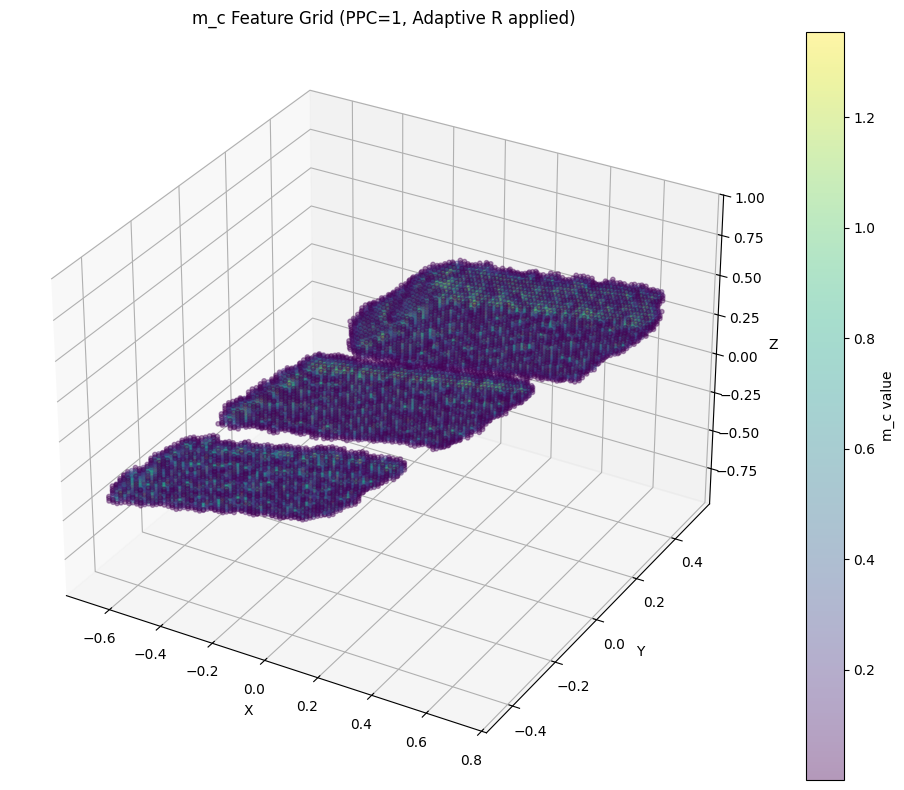

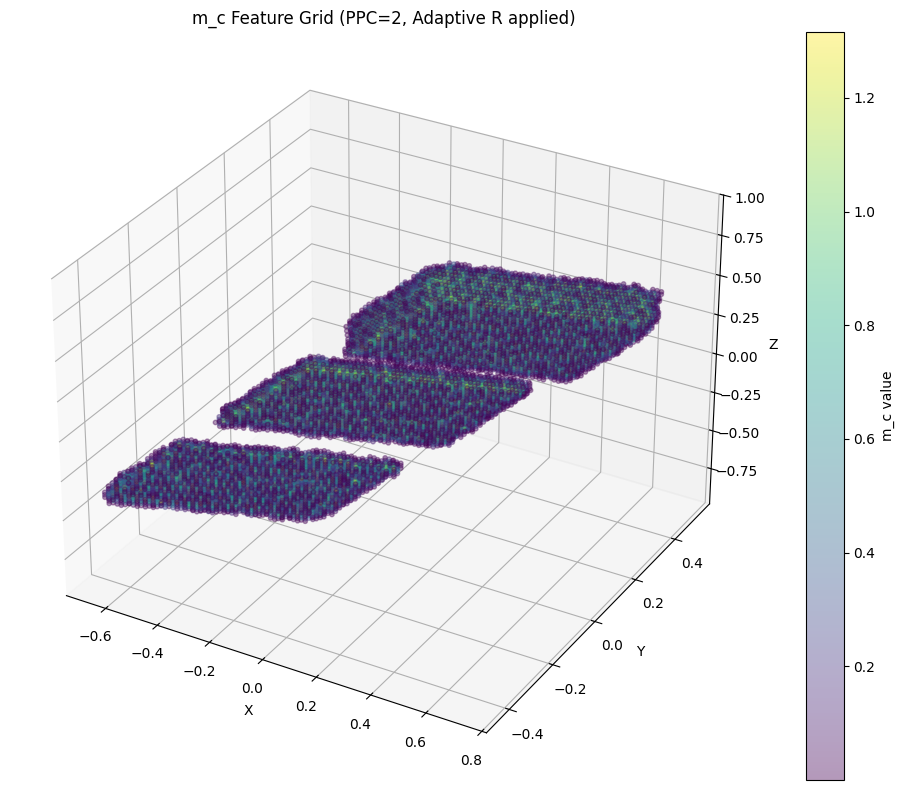

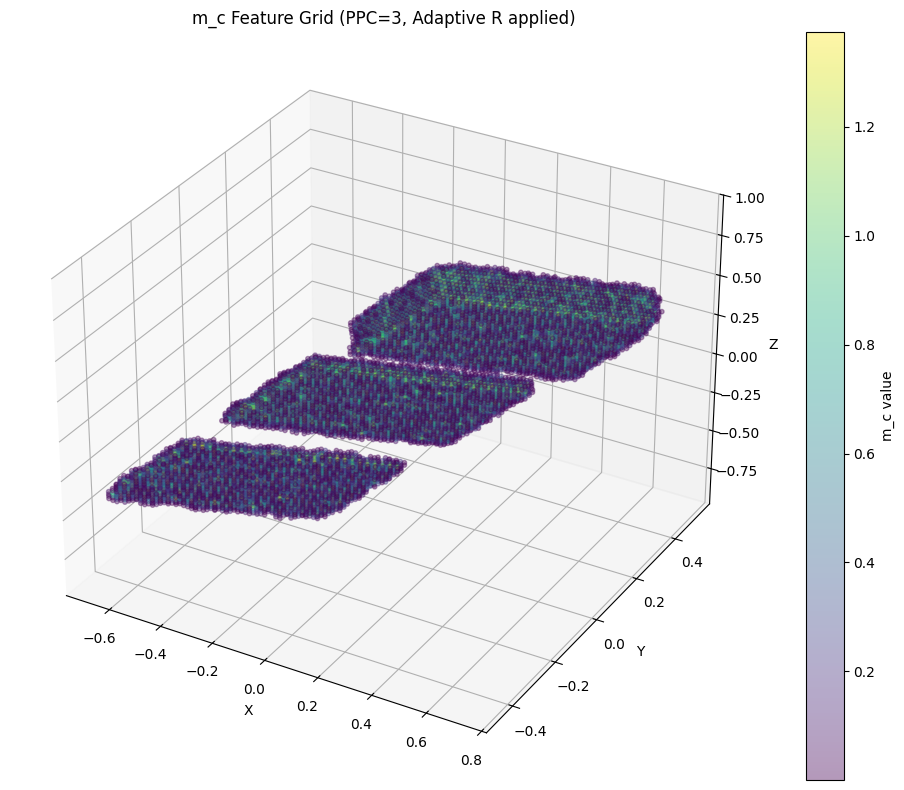

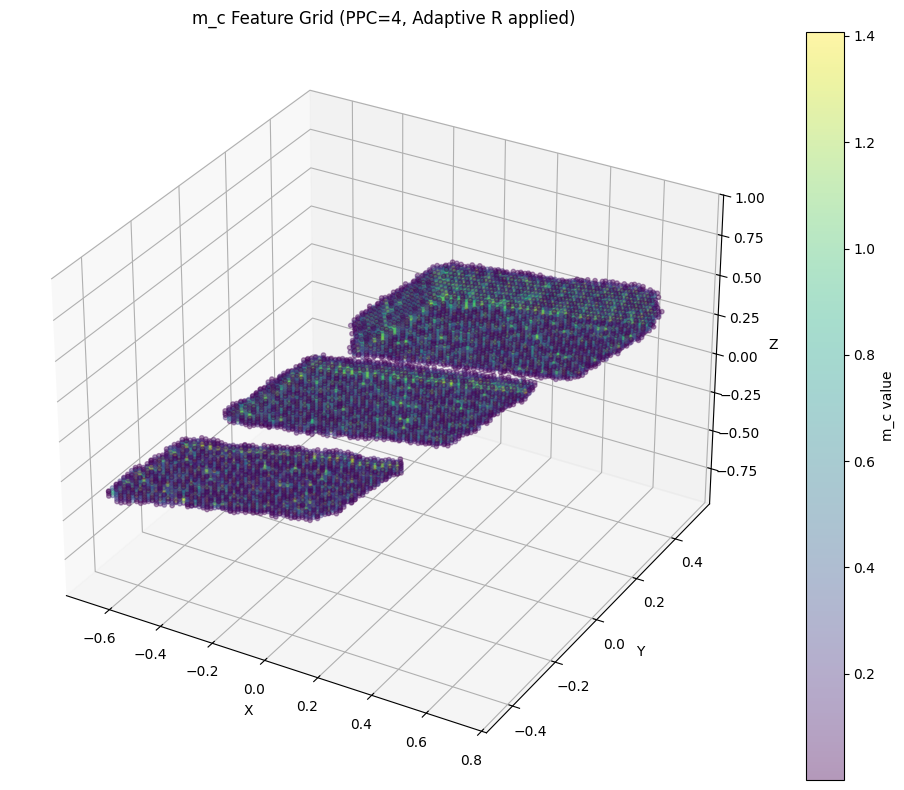

In [341]:
import os
import numpy as np
import matplotlib.pyplot as plt
import torch

# 기존 모듈 임포트
from modules.config import config
from modules.sdf_network import FeatureConstruction
from modules.visualizer import visualize_feature_grid

# ==========================================
# 1. 설정 및 공통 Grid Nodes 복원
# ==========================================
save_dir = "./dataset_ppc_test"
ppc_list = [1, 2, 3, 4]

print("⚙️ 공통 Grid Nodes 3D 좌표 복원 중...")
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
# dx와 도메인 사이즈만 있으면 동일한 격자 좌표를 얻을 수 있습니다.
grid_nodes_tensor, _ = feature_constructor.create_grid()
grid_nodes_np = grid_nodes_tensor.cpu().numpy()

# ==========================================
# 2. 저장된 파일 로드 및 시각화
# ==========================================
for ppc in ppc_list:
    current_spacing = config.dx / (ppc ** (1.0 / 3.0))
    feature_constructor = FeatureConstruction(dx=config.dx, 
        particle_spacing=current_spacing, device=device)
    mc_filename = os.path.join(save_dir, f"mc_grid_ppc{ppc}.npy")
    
    if not os.path.exists(mc_filename):
        print(f"❌ 파일을 찾을 수 없습니다: {mc_filename}")
        continue
        
    # .npy 파일에서 m_c 데이터 로드
    m_c_grid = np.load(mc_filename)
    
    print(f"📊 [PPC = {ppc}] 시각화 준비 완료")
    
    # 띄울 그래프(Figure) 생성
    fig = visualize_feature_grid(
        m_c_grid=m_c_grid,
        grid_nodes=grid_nodes_np,
        title=f"m_c Feature Grid (PPC={ppc}, Adaptive R applied)"
    )

plt.show()

Particle Input

✅ 기하학적 특징 추출 완료
   - Grid Shape: (128, 128, 128)
   - m_c 통계: Min=0.0000, Max=1.4068

[Phase 4] 💾 생성된 데이터를 .npy 형식으로 저장 중...


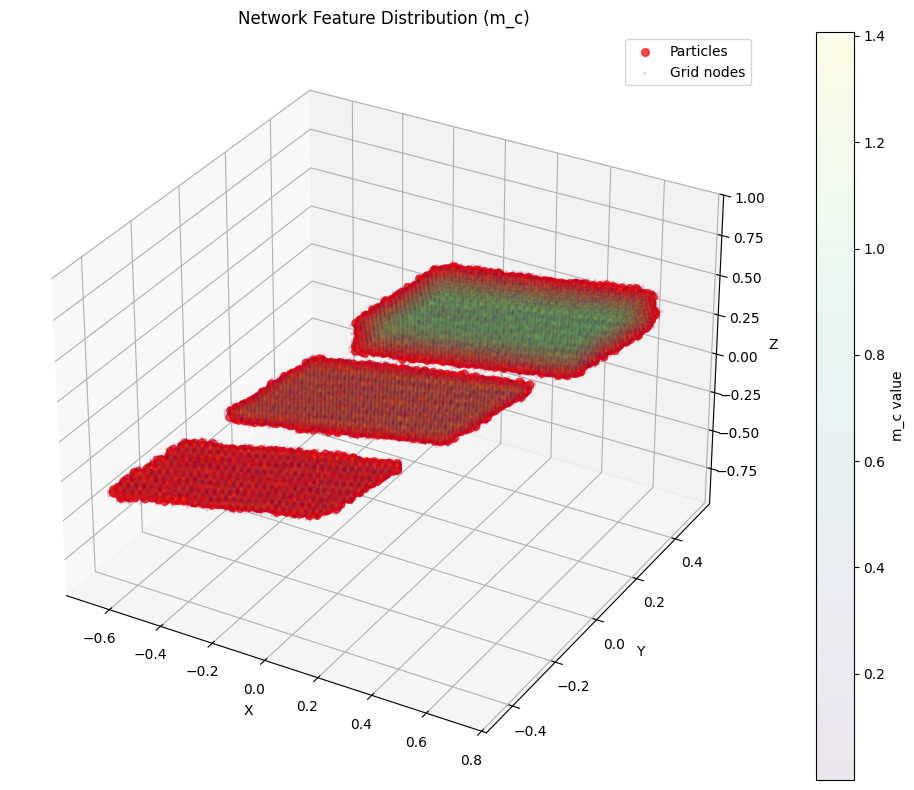

In [336]:

particles_tensor = torch.tensor(particles, dtype=torch.float32, device=device)

# 파티클 위치 기반으로 동적 그리드 변환 
grid_nodes, m_c, grid_shape = feature_constructor(particles_tensor)
m_c_grid = m_c.reshape(grid_shape).cpu().numpy()

print(f"✅ 기하학적 특징 추출 완료")
print(f"   - Grid Shape: {grid_shape}")
print(f"   - m_c 통계: Min={m_c.min():.4f}, Max={m_c.max():.4f}")

# ==========================================
# Phase 4: 데이터 저장 (.npy)
# ==========================================
print("\n[Phase 4] 💾 생성된 데이터를 .npy 형식으로 저장 중...")

# 출력 폴더 생성 (선택 사항, 깔끔한 관리를 위해)
save_dir = "./"
os.makedirs(save_dir, exist_ok=True)

# 텐서로 남아있는 grid_nodes를 numpy로 변환
grid_nodes_np = grid_nodes.cpu().numpy() if isinstance(grid_nodes, torch.Tensor) else grid_nodes


# 4-2. 파티클 분포와 네트워크의 m_c 추출 결과 뷰어
visualize_particles_and_features(
    particles=particles_tensor.cpu(),
    grid_nodes=grid_nodes.cpu(),
    m_c_grid=m_c_grid,
    title="Network Feature Distribution (m_c)"
)


In [337]:
import numpy as np
import matplotlib.pyplot as plt
from modules.config import config
from modules.particle_sampler import sample_particles_poisson
from modules.visualizer import visualize_simulation

print("=== 현재 디렉토리의 sdf_grid_64.npy 시각화 및 파티클 샘플링 ===")

# 1. 원본 SDF 데이터 불러오기
file_path = "sdf_grid_64.npy"
try:
    sdf_grid = np.load(file_path)
    print(f"✅ 데이터 로드 성공: {file_path} (Shape: {sdf_grid.shape})")
except FileNotFoundError:
    print(f"❌ 파일을 찾을 수 없습니다: {file_path}")
    sdf_grid = None
    
if sdf_grid is not None:
    # 2. 파티클 샘플링
    print("\n[파티클 샘플링 중...]")
    particles = sample_particles_poisson(sdf_grid, config)
    print(f"✅ 추출된 파티클 갯수: {len(particles)}")
    # 3. 파티클 위치 기반으로 동적 그리드 변환 및 m_c 계산
    print("\n[DirectML 가속으로 m_c 특징값 계산 중...]")
    feature_constructor = FeatureConstruction(dx=config.dx, device=device)
    particles_tensor = torch.tensor(particles, dtype=torch.float32, device=device)
    
    # 🌟 기존에 구현되어 있는 통합 함수 호출!
    grid_nodes, m_c, grid_shape = feature_constructor(particles_tensor)
    
    # 3D 텐서(64x64x64)로 복원 후 numpy 배열로 변환
    mc_grid = m_c.reshape(grid_shape).cpu().numpy()
    
    # 4. 결과 저장 (mc_grid_64.npy)
    save_path = "mc_grid_64.npy"
    # np.save(save_path, mc_grid)
    print(f"✅ m_c 그리드 저장 완료: {save_path} (Shape: {mc_grid.shape})")
    # 5. m_c 3D 특징 맵 시각화
    print("\n[m_c 특징 공간 시각화]")
    fig = visualize_feature_grid(
        m_c_grid=m_c,             # flatten된 1D 텐서 그대로 투입
        grid_nodes=grid_nodes,    # 짝이 완벽하게 맞는 3D 좌표 노드
        title="Computed m_c Feature Grid (from sdf_grid_64.npy)"
    )
    plt.show()

=== 현재 디렉토리의 sdf_grid_64.npy 시각화 및 파티클 샘플링 ===
❌ 파일을 찾을 수 없습니다: sdf_grid_64.npy


📥 m_c 데이터 로드: mc_grid_128.npy (Shape: (128, 128, 128))


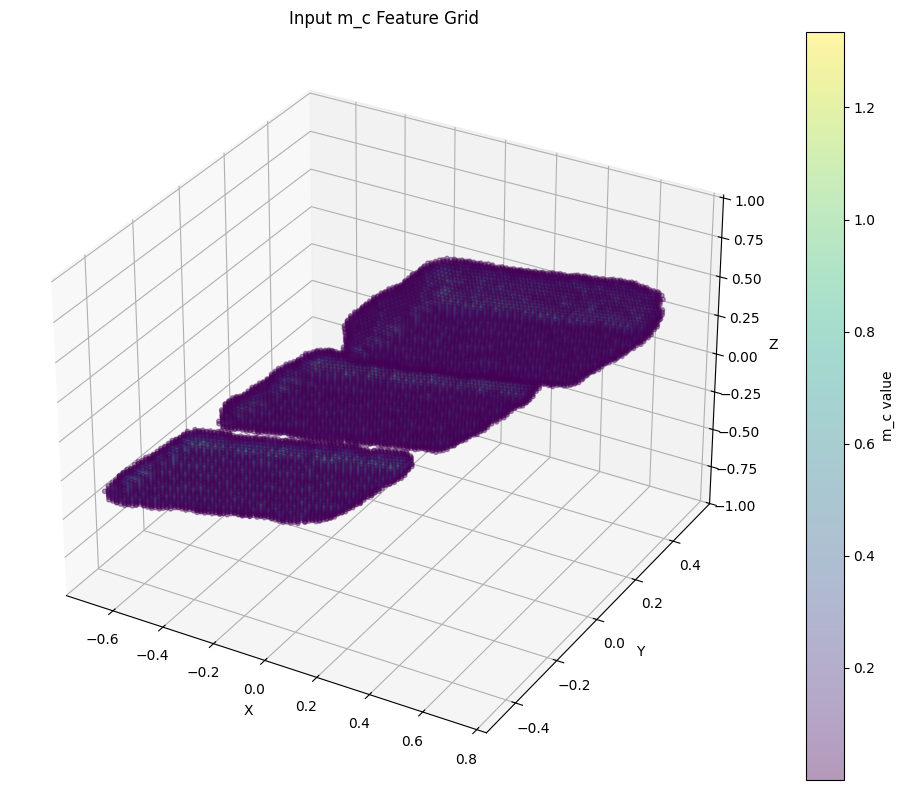

In [338]:
# 1. 확인할 데이터 인덱스 설정 (0 ~ 4)
sdf_file = f"sdf_grid_128.npy"
mc_file = f"mc_grid_128.npy"

# 2. 데이터 로드 완료
sdf_grid = np.load(sdf_file)
mc_grid = np.load(mc_file)
print(f"📥 m_c 데이터 로드: {mc_file} (Shape: {mc_grid.shape})")

fig2 = visualize_feature_grid(
    m_c_grid=mc_grid,         # 앞서 파이프라인에서 나온 mc_grid 텐서 그대로 삽입
    grid_nodes=grid_nodes,    # 앞서 파이프라인에서 나온 grid_nodes 텐서 그대로 삽입
    title=f"Input m_c Feature Grid"
)

### 3.3 학습

디바이스/데이터로더 설정 셀

훈련 반복문 셀

In [325]:
import time
import numpy as np
import torch
import torch.optim as optim
from tqdm import tqdm

from modules.dataset import SDFDataset, DataLoader
from modules.sdf_network import SDFNetwork, PolynomialRegularizedSDFLoss, SDFReconstruction, FeatureConstruction
from modules.config import config
from modules.visualizer import visualize_simulation

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"⚡ 작동 디바이스: {device}")

# ==========================================
# 📦 1. 데이터 로드 (Narrow Band 적용)
# ==========================================
print("\n[데이터 로드 시작]")

train_dataset = SDFDataset(
    data_dirs=["dataset4"] ,   # 🚨 경로 확인 (dataset4)
    patch_size=8,
    in_memory=True, 
    use_narrow_band=True, 
    use_bg_sample=False,     
    bg_sample_ratio=0.10,
    max_samples=10000000
)
# 공통 학습 파라미터 세팅 (빠른 실험을 위해 데이터의 50%만 학습)
num_epochs = 5
max_batches = len(train_loader)
train_loader = DataLoader(train_dataset, batch_size=256, shuffle=True, num_workers=0)

⚡ 작동 디바이스: cuda

[데이터 로드 시작]
💾 총 50쌍의 데이터를 메모리에 캐싱 중입니다...
✅ 캐싱 완료.
🔍 [초고속 필터링] 표면(|SDF| <= 0.0312) 샘플링 중...
✂️ [데이터 제한] 전체 14,560,839개 샘플 중 무작위 10,000,000개만 선택되었습니다.
✅ 샘플링 완료!
   - 표면(Narrow Band) 데이터: 14560839개 (100% 사용)
   - 최종 학습 데이터: 10000000개 (전체 중 9.5%)


In [62]:
import time
import numpy as np
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt

# 사용자 정의 모듈 임포트 (경로는 본인 환경에 맞게 유지)
from modules.sdf_network import SDFNetwork, SDFReconstruction
from modules.config import config
from modules.visualizer import visualize_simulation

print("=== [Step 5] 저장된 가중치 불러오기 및 다이렉트 SDF 추론 ===")

# -------------------------------------------------------------------
# [핵심 수정 사항] 진짜 신경망 모델(SDFNetwork)을 불러옵니다!
# -------------------------------------------------------------------
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# 1. 빈 모델 껍데기(구조) 생성
model = SDFNetwork().to(device)

# 2. 가중치 파일 경로 및 로드
weights_path = "sdf_network_cpu.pth"
model.load_state_dict(torch.load(weights_path, map_location=device))

# 3. 평가(eval) 모드로 전환
model.eval()

print(f"✅ '{weights_path}' 가중치 로드 완료! (Device: {device})")


=== [Step 5] 저장된 가중치 불러오기 및 다이렉트 SDF 추론 ===


C:\Users\user00\AppData\Local\Temp\ipykernel_27084\3900679197.py:24: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(weights_path, map_locatio

RuntimeError: Error(s) in loading state_dict for SDFNetwork:
	size mismatch for fc3.weight: copying a param with shape torch.Size([1, 128]) from checkpoint, the shape in current model is torch.Size([27, 128]).
	size mismatch for fc3.bias: copying a param with shape torch.Size([1]) from checkpoint, the shape in current model is torch.Size([27]).

In [326]:

# ==========================================
# 🧪 [실험 1] 다항식 정규화(Polynomial) + MSE 
# ==========================================
print("\n" + "="*55)
print(">> 🧪 [실험 1] 다항식 정규화(Poly) + MSE 모드 학습 시작")
print("="*55)

model_poly = SDFNetwork().to(device)
optimizer_poly = optim.Adam(model_poly.parameters(), lr=0.0002)
criterion_poly = PolynomialRegularizedSDFLoss(lambda_reg=1.0, use_poly_loss=True).to(device)

start_time = time.time()
model_poly.train_step(
    train_loader=train_loader,
    optimizer=optimizer_poly,
    criterion=criterion_poly,
    device=device,
    num_epochs=num_epochs,
    max_batches_per_epoch=max_batches
)
print(f"✅ 실험 1 학습 완료! (소요 시간: {time.time() - start_time:.1f}초)")





>> 🧪 [실험 1] 다항식 정규화(Poly) + MSE 모드 학습 시작


Epoch [01/05]: 100%|██████████| 39063/39063 [15:44<00:00, 41.36it/s, loss=0.00001]


✅ Epoch 1 완료! 평균 Loss: 0.000267



Epoch [02/05]: 100%|██████████| 39063/39063 [15:24<00:00, 42.25it/s, loss=0.00001]


✅ Epoch 2 완료! 평균 Loss: 0.000011



...

✅ Epoch 3 완료! 평균 Loss: 0.000010



Epoch [04/05]: 100%|██████████| 39063/39063 [15:14<00:00, 42.71it/s, loss=0.00001]


✅ Epoch 4 완료! 평균 Loss: 0.000010



Epoch [05/05]: 100%|██████████| 39063/39063 [15:13<00:00, 42.77it/s, loss=0.00001]

✅ Epoch 5 완료! 평균 Loss: 0.000010

✅ 실험 1 학습 완료! (소요 시간: 4612.9초)


In [260]:
# ==========================================
# 🧪 [실험 2] 순수 MSE 모드 (정규화 제거 비교용)
# ==========================================
print("\n" + "="*55)
print(">> 🧪 [실험 2] 순수 MSE 모드 학습 시작 (Poly OFF)")
print("="*55)

# 🚨 이전 모델의 기억을 지우고 완전히 새로운 모델 생성
model_mse = SDFNetwork().to(device)
optimizer_mse = optim.Adam(model_mse.parameters(), lr=0.0002)
# 🚨 use_poly_loss=False (정규화 OFF)
criterion_mse = PolynomialRegularizedSDFLoss(use_poly_loss=False).to(device)

start_time = time.time()
model_mse.train_step(
    train_loader=train_loader,
    optimizer=optimizer_mse,
    criterion=criterion_mse,
    device=device,
    num_epochs=num_epochs,
    max_batches_per_epoch=max_batches
)
print(f"✅ 실험 2 학습 완료! (소요 시간: {time.time() - start_time:.1f}초)")




>> 🧪 [실험 2] 순수 MSE 모드 학습 시작 (Poly OFF)


Epoch [01/05]: 100%|██████████| 32108/32108 [13:05<00:00, 40.89it/s, loss=0.00001] 


✅ Epoch 1 완료! 평균 Loss: 0.000039



Epoch [02/05]: 100%|██████████| 32108/32108 [12:58<00:00, 41.26it/s, loss=0.00001] 


✅ Epoch 2 완료! 평균 Loss: 0.000013



...

✅ Epoch 3 완료! 평균 Loss: 0.000012



Epoch [04/05]: 100%|██████████| 32108/32108 [12:59<00:00, 41.20it/s, loss=0.00001] 


✅ Epoch 4 완료! 평균 Loss: 0.000012



Epoch [05/05]: 100%|██████████| 32108/32108 [13:01<00:00, 41.06it/s, loss=0.00001] 

✅ Epoch 5 완료! 평균 Loss: 0.000012

✅ 실험 2 학습 완료! (소요 시간: 3905.5초)


In [125]:
# ==========================================
# 💾 모델 가중치 저장하기
# ==========================================
weights_path_mse = "sdf_network_mse.pth"

# 모델의 상태(가중치)를 딕셔너리 형태로 저장합니다.
torch.save(reconstructor_poly.network.state_dict(), "sdf_network_poly_27ch.pth")
print(f"💾 MSE 모델 가중치가 안전하게 저장되었습니다: {weights_path_mse}")

💾 MSE 모델 가중치가 안전하게 저장되었습니다: sdf_network_mse.pth


In [327]:
# 1. 평가용 데이터 로드 
# 🚨 핵심 변경: mc_grid.npy 대신 원본 파티클 좌표를 직접 불러옵니다!
particles_np = np.load("particles_128.npy")
particles_tensor = torch.tensor(particles_np, dtype=torch.float32, device=device)

sdf_grid_gt = np.load("sdf_grid_128.npy")  # 정답지 (기본 해상도, 비교용)
# 추론 및 시각화를 위한 평가용 데이터 로드
m_c_grid_np = np.load("mc_grid_128.npy")
m_c_grid_tensor = torch.tensor(m_c_grid_np, dtype=torch.float32)

print(">> 실험 1 추론")
reconstructor_poly = SDFReconstruction(dx=config.dx, device=device)
reconstructor_poly.network = model_poly  # 학습된 모델 장착
pred_sdf_poly = reconstructor_poly.inference(m_c_grid_tensor, patch_size=8, batch_size=2048)

print(">> 실험 2 추론")
reconstructor_mse = SDFReconstruction(dx=config.dx, device=device)
reconstructor_mse.network = model_mse  # 두 번째로 학습된 모델 장착
pred_sdf_mse = reconstructor_mse.inference(m_c_grid_tensor, patch_size=8, batch_size=2048)


>> 실험 1 추론
self.R : 0.047244094488188976
   ✂️ [Pruning ON] 2097152개 중 146154개 노드 연산 (7.0%)
>> 실험 2 추론
self.R : 0.047244094488188976
   ✂️ [Pruning ON] 2097152개 중 146154개 노드 연산 (7.0%)



=== [Step 6] 결과물 시각화 (Ablation 비교) ===


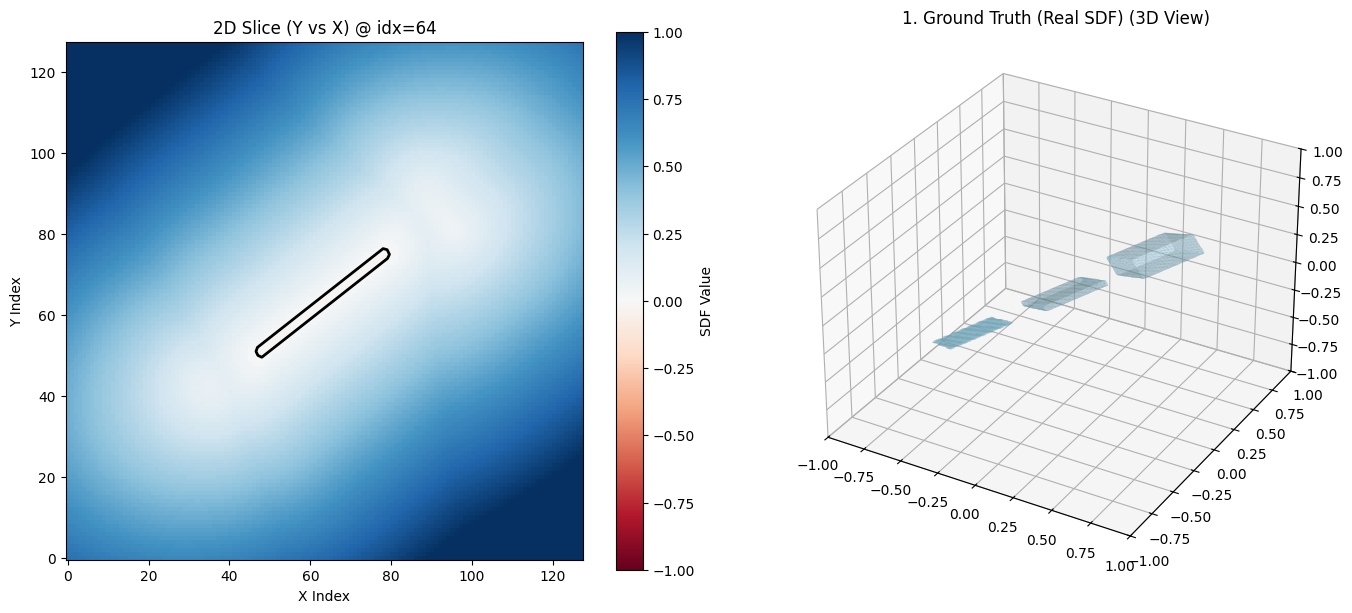

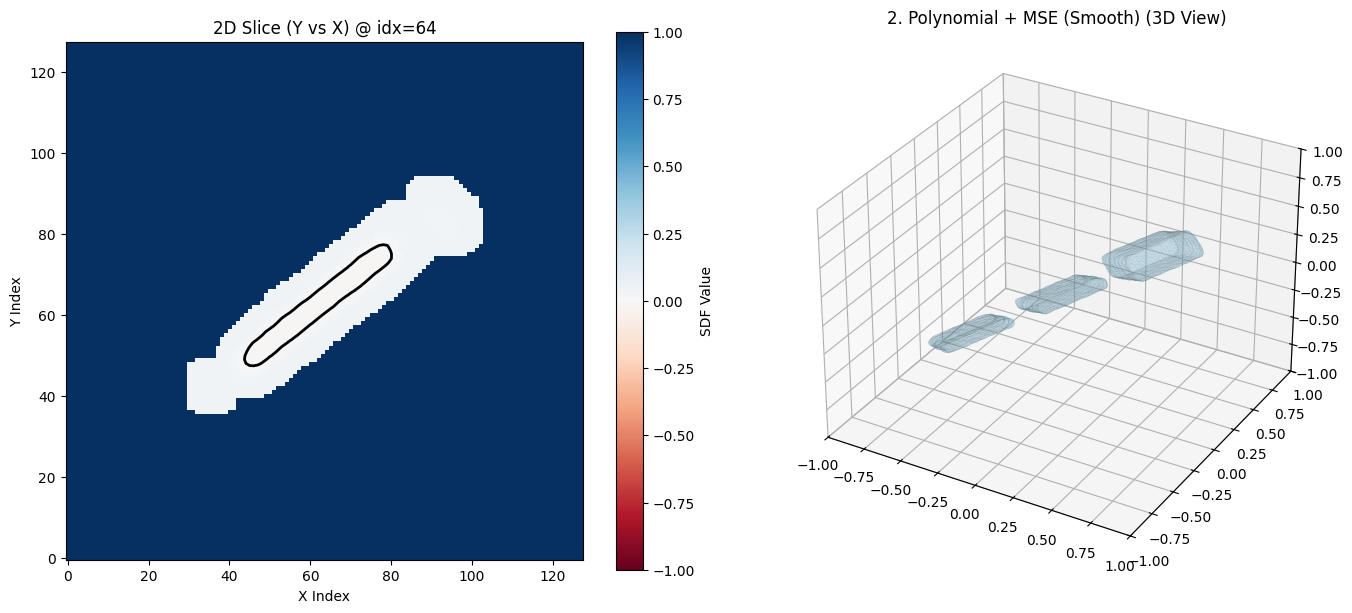

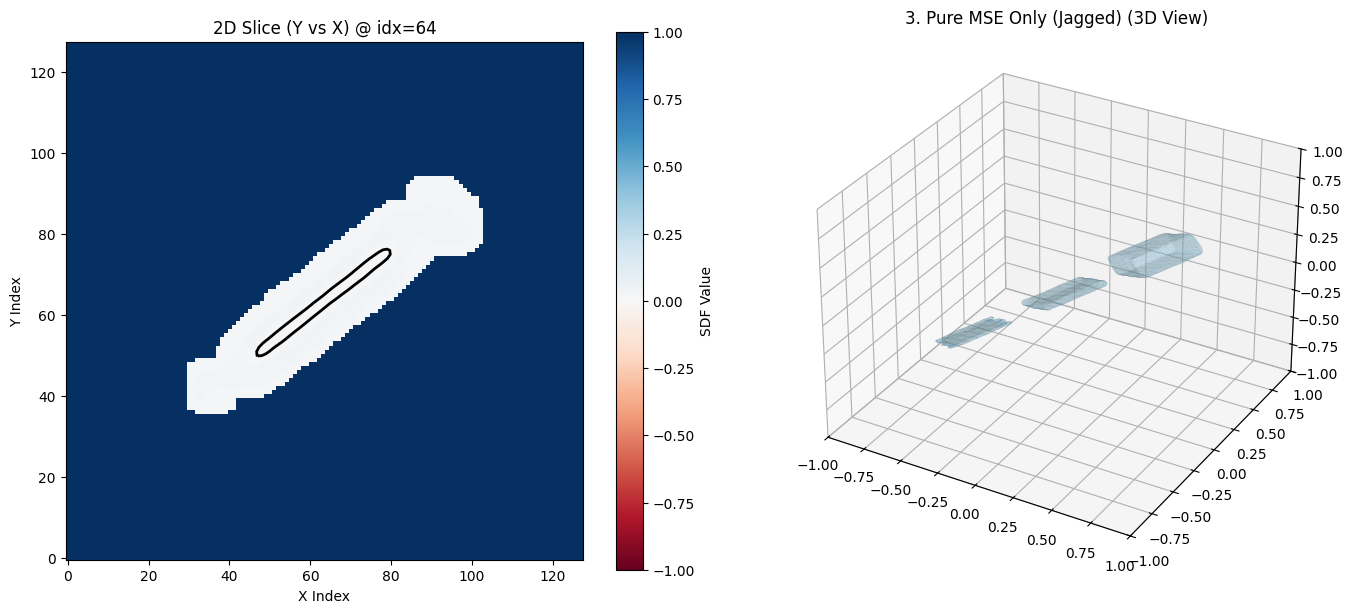

In [328]:

# ==========================================
# 📊 최종 결과 시각화 및 비교
# ==========================================
print("\n=== [Step 6] 결과물 시각화 (Ablation 비교) ===")

# 1. 정답지 (도넛 모양)
visualize_simulation(sdf_grid=sdf_grid_gt, domain_size=config.domain_size, title="1. Ground Truth (Real SDF)")

# 2. 논문 세팅 결과 (매끄러운 곡면)
visualize_simulation(sdf_grid=pred_sdf_poly.cpu().numpy(), domain_size=config.domain_size, title="2. Polynomial + MSE (Smooth)")

# 3. 정규화 끈 결과 (쭈글쭈글한 표면)
visualize_simulation(sdf_grid=pred_sdf_mse.cpu().numpy(), domain_size=config.domain_size, title="3. Pure MSE Only (Jagged)")

=== [Step 1] Ground Truth 시각화 ===


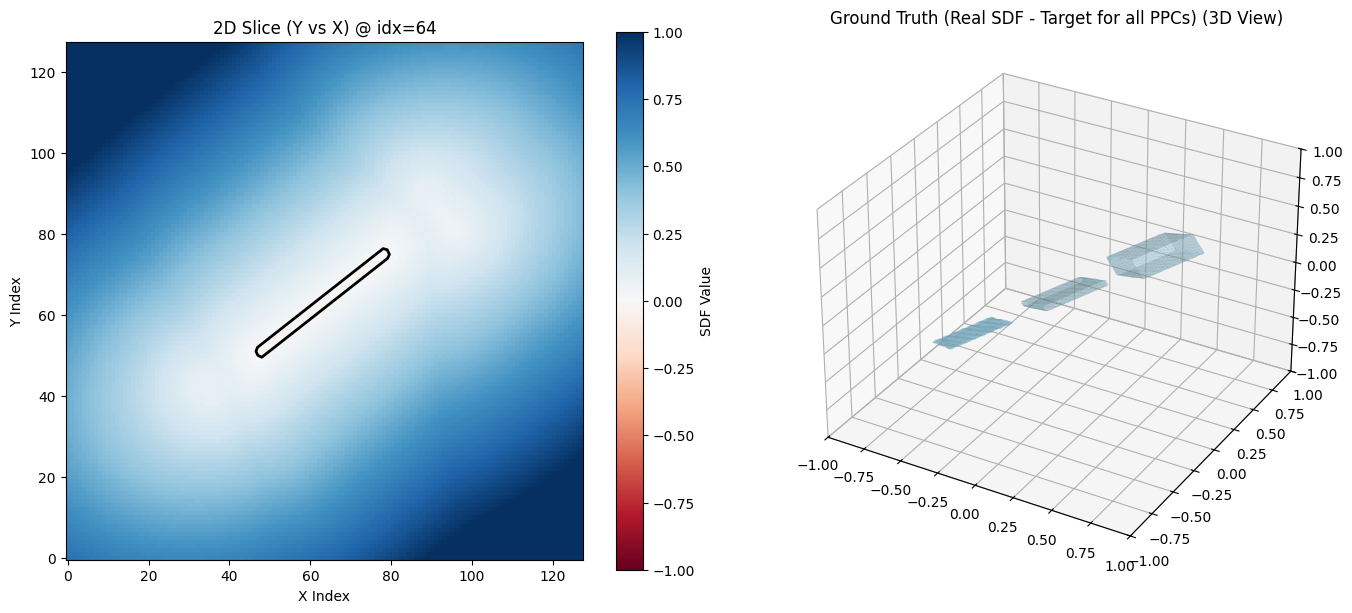


=== [Step 2] 추론기 초기화 ===
self.R : 0.047244094488188976

=== [Step 3] PPC별 추론 및 결과 비교 ===

----------------------------------------
🔍 [ PPC = 1 ] 데이터 평가 중...
   ✂️ [Pruning ON] 2097152개 중 121773개 노드 연산 (5.8%)
   📉 측정된 MSE 오차: 0.224351


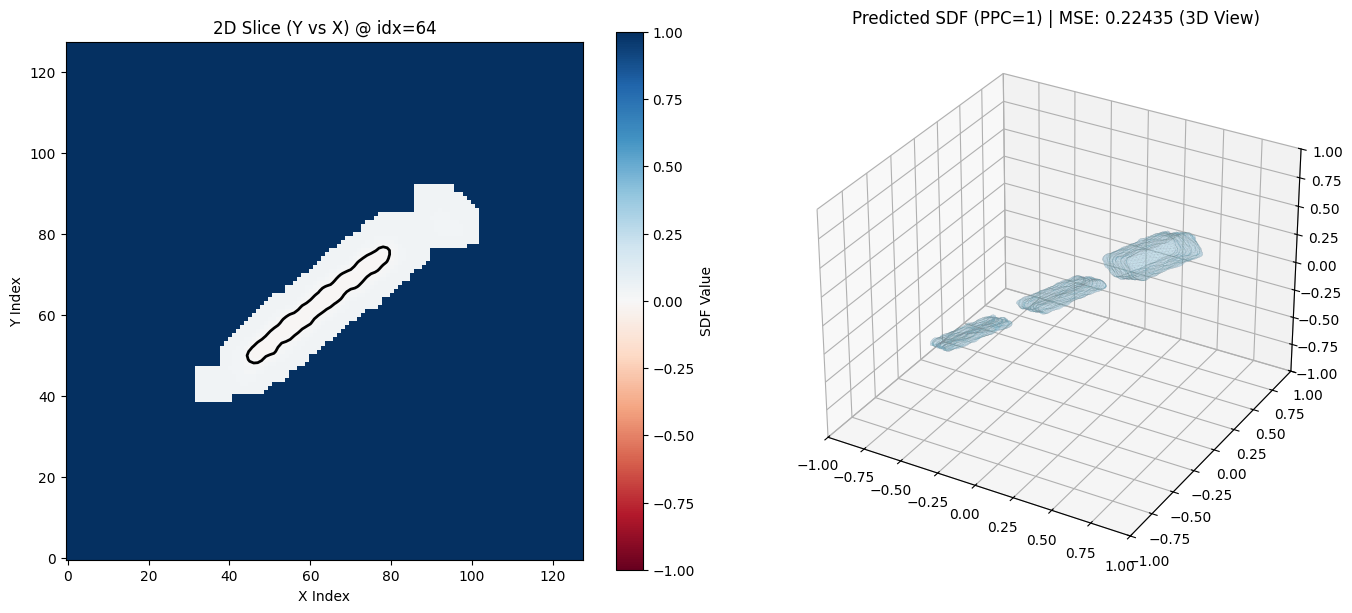


----------------------------------------
🔍 [ PPC = 2 ] 데이터 평가 중...
   ✂️ [Pruning ON] 2097152개 중 114427개 노드 연산 (5.5%)
   📉 측정된 MSE 오차: 0.227126


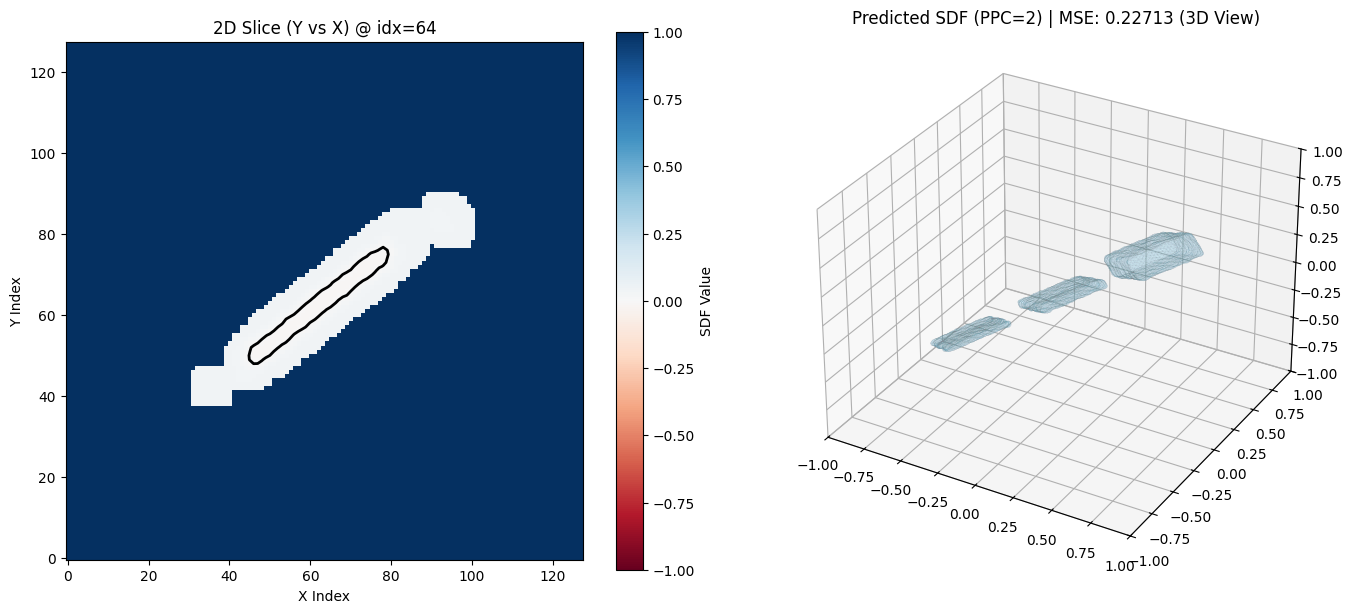


----------------------------------------
🔍 [ PPC = 3 ] 데이터 평가 중...
   ✂️ [Pruning ON] 2097152개 중 113264개 노드 연산 (5.4%)
   📉 측정된 MSE 오차: 0.227565


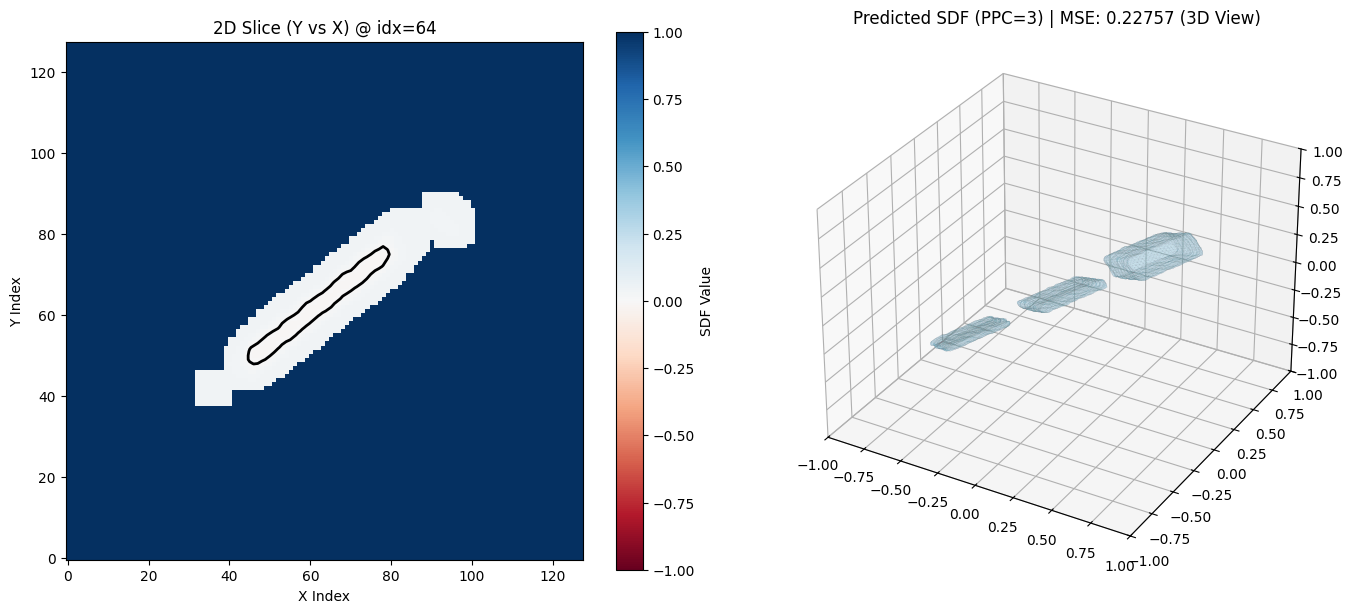


----------------------------------------
🔍 [ PPC = 4 ] 데이터 평가 중...
   ✂️ [Pruning ON] 2097152개 중 112520개 노드 연산 (5.4%)
   📉 측정된 MSE 오차: 0.227850


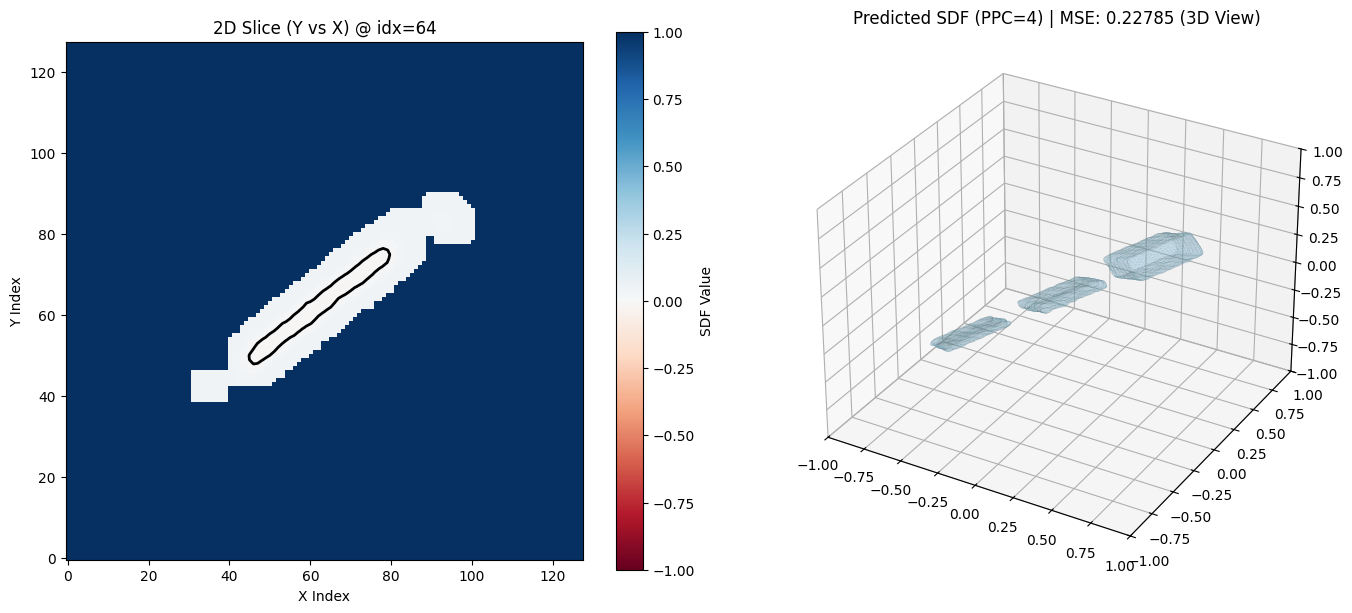


🎉 모든 PPC에 대한 추론 및 시각화가 완료되었습니다!


In [342]:
import torch
import numpy as np
import os

# (config, SDFReconstruction, visualize_simulation, model_poly 등은 이미 로드/정의되었다고 가정합니다)

save_dir = "./dataset_ppc_test"
ppc_list = [1, 2, 3, 4]
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# ==========================================
# 1. 정답지(Ground Truth) 로드 및 시각화
# ==========================================
gt_path = os.path.join(save_dir, "sdf_grid_base.npy")
sdf_grid_gt = np.load(gt_path)

print("=== [Step 1] Ground Truth 시각화 ===")
visualize_simulation(
    sdf_grid=sdf_grid_gt, 
    domain_size=config.domain_size, 
    title="Ground Truth (Real SDF - Target for all PPCs)"
)

# ==========================================
# 2. Reconstructor 초기화 (학습된 모델 장착)
# ==========================================
print("\n=== [Step 2] 추론기 초기화 ===")
reconstructor_poly = SDFReconstruction(dx=config.dx, device=device)
reconstructor_poly.network = model_poly  # 학습이 완료된 모델 객체 연결

# ==========================================
# 3. PPC별 순회 추론 및 시각화 (Ablation Study)
# ==========================================
print("\n=== [Step 3] PPC별 추론 및 결과 비교 ===")

for ppc in ppc_list:
    print(f"\n{'-'*40}")
    print(f"🔍 [ PPC = {ppc} ] 데이터 평가 중...")
    
    # 1) 개별 m_c 특징맵 로드
    mc_filename = os.path.join(save_dir, f"mc_grid_ppc{ppc}.npy")
    if not os.path.exists(mc_filename):
        print(f"❌ 파일을 찾을 수 없습니다: {mc_filename}")
        continue
        
    m_c_grid_np = np.load(mc_filename)
    m_c_grid_tensor = torch.tensor(m_c_grid_np, dtype=torch.float32)
    
    # 2) 네트워크 추론 (Inference)
    pred_sdf_poly = reconstructor_poly.inference(
        m_c_grid_tensor, 
        patch_size=8, 
        batch_size=2048
    )
    pred_sdf_np = pred_sdf_poly.cpu().numpy()
    
    # 3) 정량적 평가 (MSE Error 계산)
    # 정답지와 예측지 간의 오차를 수치화하여 객관적 지표 획득
    mse_error = np.mean((sdf_grid_gt - pred_sdf_np) ** 2)
    print(f"   📉 측정된 MSE 오차: {mse_error:.6f}")
    
    # 4) 시각화 (도형 렌더링)
    visualize_simulation(
        sdf_grid=pred_sdf_np, 
        domain_size=config.domain_size, 
        title=f"Predicted SDF (PPC={ppc}) | MSE: {mse_error:.5f}"
    )

print("\n🎉 모든 PPC에 대한 추론 및 시각화가 완료되었습니다!")

In [ ]:
print("\n" + "="*55)
print(">> 🎯 [실험 1] Poly 모델 고해상도(Staggered) 추론 시작")
print("="*55)
reconstructor_poly = SDFReconstruction(dx=config.dx, device=device)
reconstructor_poly.network = model_poly  # 첫 번째로 학습된 모델 장착

start_time = time.time()
# 🚨 inference 대신 staggered_inference 호출!
# 내부적으로 Pruning이 8번 작동하여 연산 속도를 크게 단축시킵니다.
pred_sdf_poly_high_res = reconstructor_poly.staggered_inference(
    particles_tensor, 
    patch_size=8, 
    batch_size=2048
)
print(f"   -> ⏱️ Poly 모델 총 소요 시간: {time.time() - start_time:.1f}초\n")


print("="*55)
print(">> 🎯 [실험 2] MSE 모델 고해상도(Staggered) 추론 시작")
print("="*55)
reconstructor_mse = SDFReconstruction(dx=config.dx, device=device)
reconstructor_mse.network = model_mse  # 두 번째로 학습된 모델 장착

start_time = time.time()
pred_sdf_mse_high_res = reconstructor_mse.staggered_inference(
    particles_tensor, 
    patch_size=8, 
    batch_size=2048
)
print(f"   -> ⏱️ MSE 모델 총 소요 시간: {time.time() - start_time:.1f}초\n")


>> 🎯 [실험 1] Poly 모델 고해상도(Staggered) 추론 시작
self.R : 0.047244094488188976
🚀 [Staggered Reconstruction] 해상도(2배) 레벨셋 복원
 ⏳ 엇갈린 그리드 추론 중... 조합: a=0, b=0, c=0 (Offset: (0.0, 0.0, 0.0))
   ✂️ [Pruning ON] 2097152개 중 146154개 노드 연산 (7.0%)
 ⏳ 엇갈린 그리드 추론 중... 조합: a=0, b=0, c=1 (Offset: (0.0, 0.0, 0.007874015748031496))
   ✂️ [Pruning ON] 2097152개 중 146396개 노드 연산 (7.0%)
 ⏳ 엇갈린 그리드 추론 중... 조합: a=0, b=1, c=0 (Offset: (0.0, 0.007874015748031496, 0.0))
   ✂️ [Pruning ON] 2097152개 중 147048개 노드 연산 (7.0%)
 ⏳ 엇갈린 그리드 추론 중... 조합: a=0, b=1, c=1 (Offset: (0.0, 0.007874015748031496, 0.007874015748031496))
   ✂️ [Pruning ON] 2097152개 중 147021개 노드 연산 (7.0%)
 ⏳ 엇갈린 그리드 추론 중... 조합: a=1, b=0, c=0 (Offset: (0.007874015748031496, 0.0, 0.0))
   ✂️ [Pruning ON] 2097152개 중 147300개 노드 연산 (7.0%)
 ⏳ 엇갈린 그리드 추론 중... 조합: a=1, b=0, c=1 (Offset: (0.007874015748031496, 0.0, 0.007874015748031496))
   ✂️ [Pruning ON] 2097152개 중 147252개 노드 연산 (7.0%)
 ⏳ 엇갈린 그리드 추론 중... 조합: a=1, b=1, c=0 (Offset: (0.007874015748031496, 0.007874015

=== 📊 고해상도 결과물 시각화 ===
💡 참고: Ground Truth는 기본 해상도(N)이며, 예측 결과는 2배 해상도(2N)입니다.


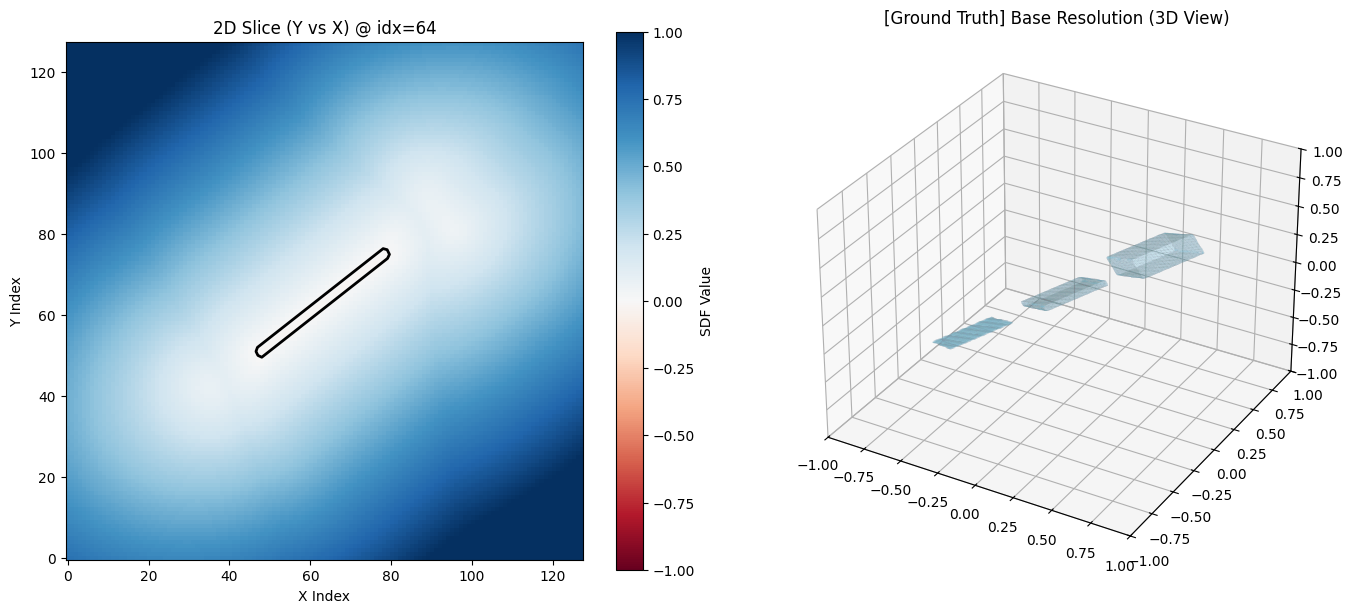

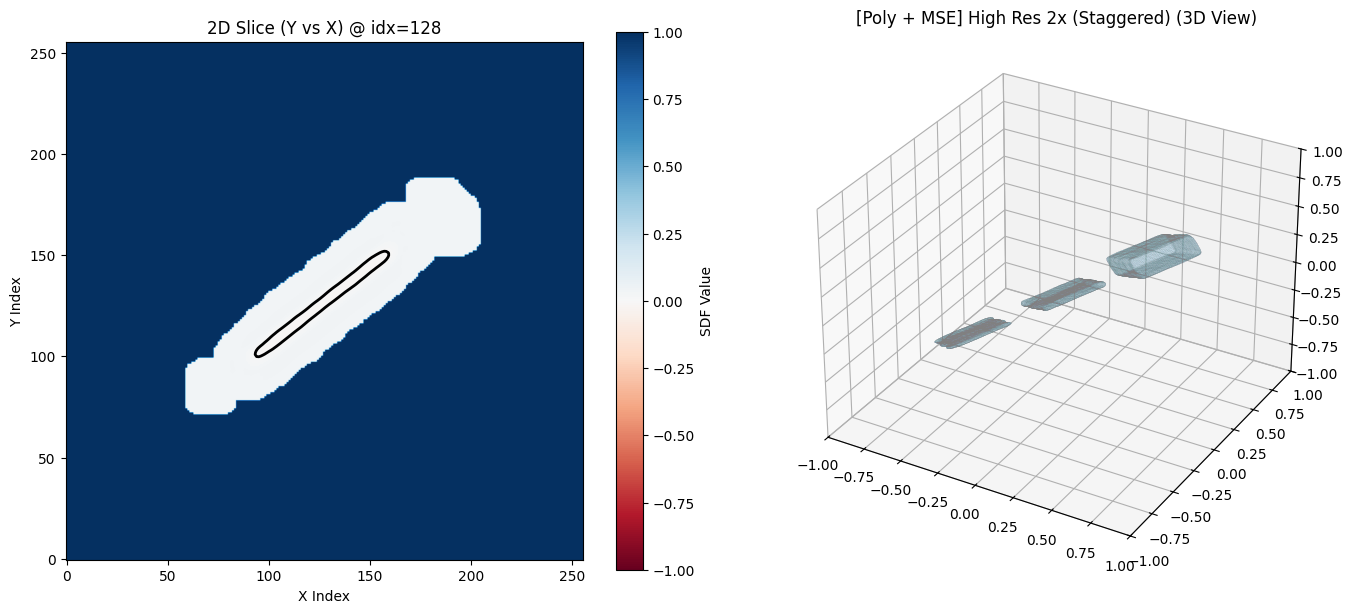

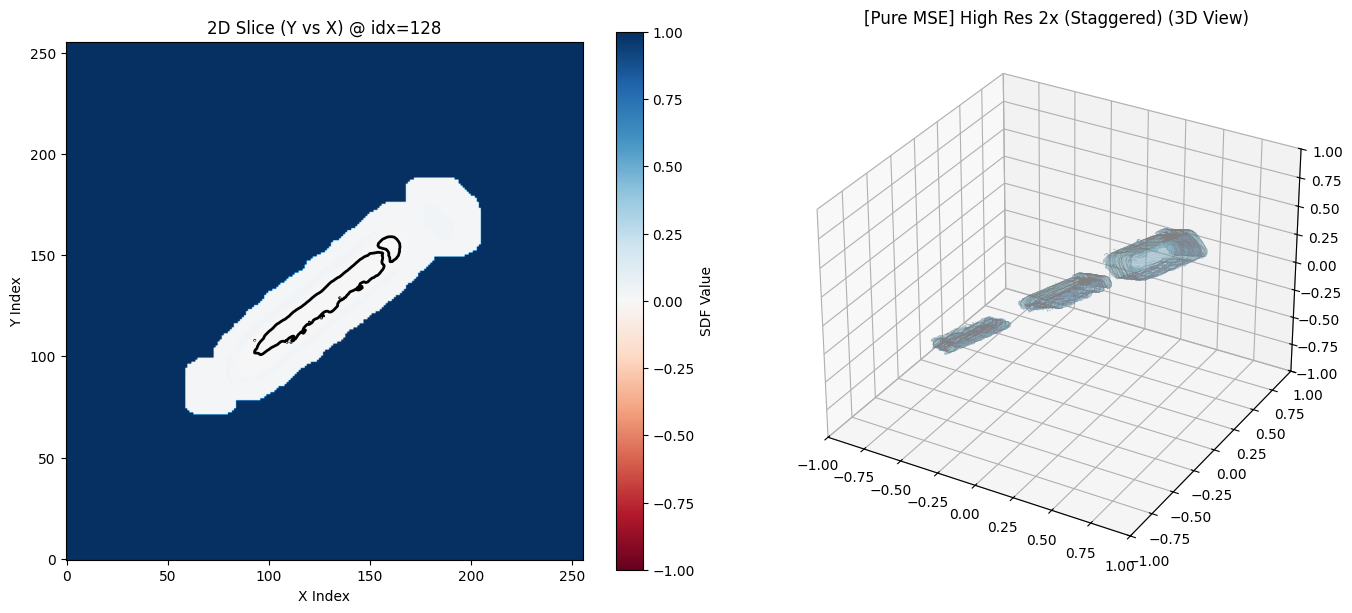

In [270]:
# ==========================================
# 📊 결과 시각화 및 비교
# ==========================================
print("=== 📊 고해상도 결과물 시각화 ===")
print("💡 참고: Ground Truth는 기본 해상도(N)이며, 예측 결과는 2배 해상도(2N)입니다.")

# 1. 정답지 (기본 해상도)
visualize_simulation(
    sdf_grid=sdf_grid_gt, 
    domain_size=config.domain_size, 
    title="[Ground Truth] Base Resolution"
)

# 2. 논문 세팅 결과 (2배 해상도 + 정규화로 매우 매끄러움)
visualize_simulation(
    sdf_grid=pred_sdf_poly_high_res.cpu().numpy(), 
    domain_size=config.domain_size, 
    title="[Poly + MSE] High Res 2x (Staggered)"
)

# 3. 정규화 끈 결과 (2배 해상도지만 표면이 울퉁불퉁할 수 있음)
visualize_simulation(
    sdf_grid=pred_sdf_mse_high_res.cpu().numpy(), 
    domain_size=config.domain_size, 
    title="[Pure MSE] High Res 2x (Staggered)"
)


>> 🎯 특정 테스트 데이터(Shape 100) 추론 시작
>> Poly 모델(정규화 ON)로 Shape 100 추론 중...
   ✂️ [Pruning ON] 2146689개 중 633317개 노드 연산 (29.5%)
>> MSE 모델(정규화 OFF)로 Shape 100 추론 중...
   ✂️ [Pruning ON] 2146689개 중 633317개 노드 연산 (29.5%)

=== [Step 7] Shape 100 결과물 시각화 (Unseen Data Test) ===


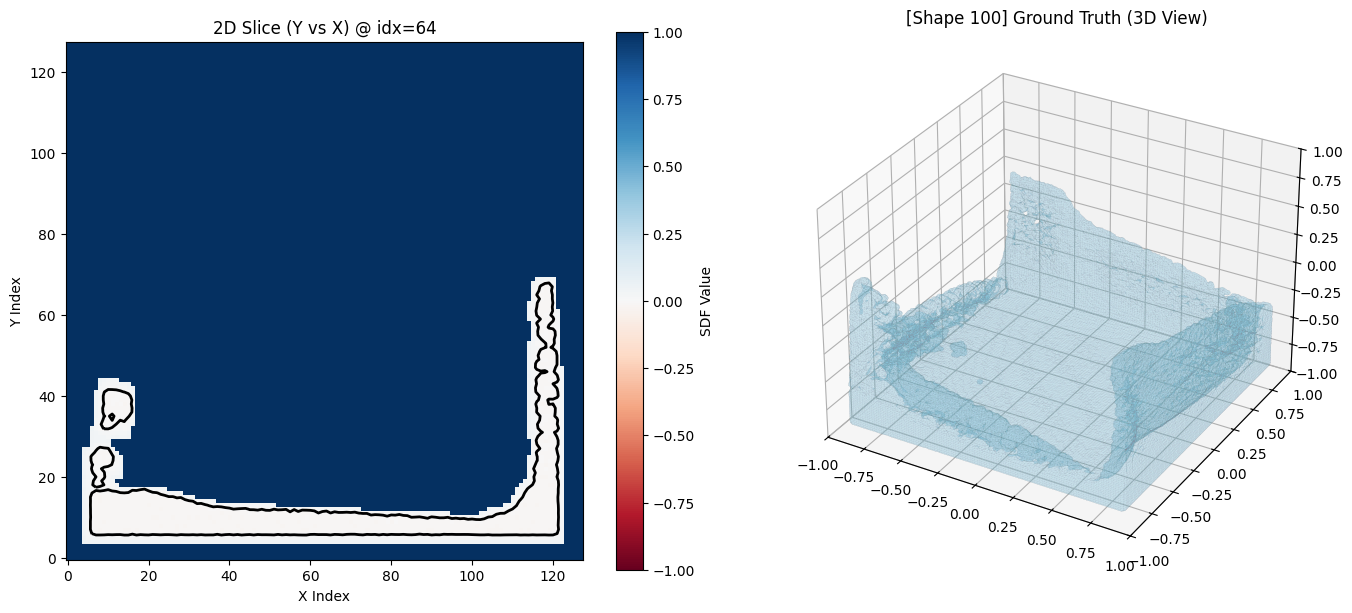

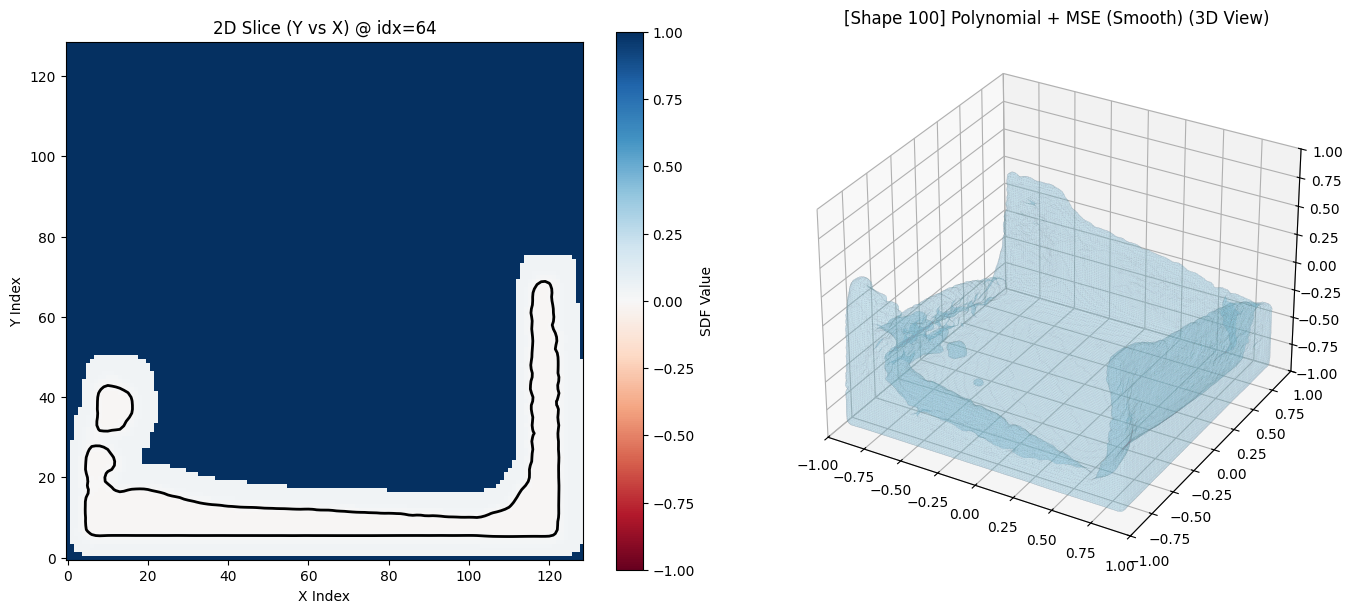

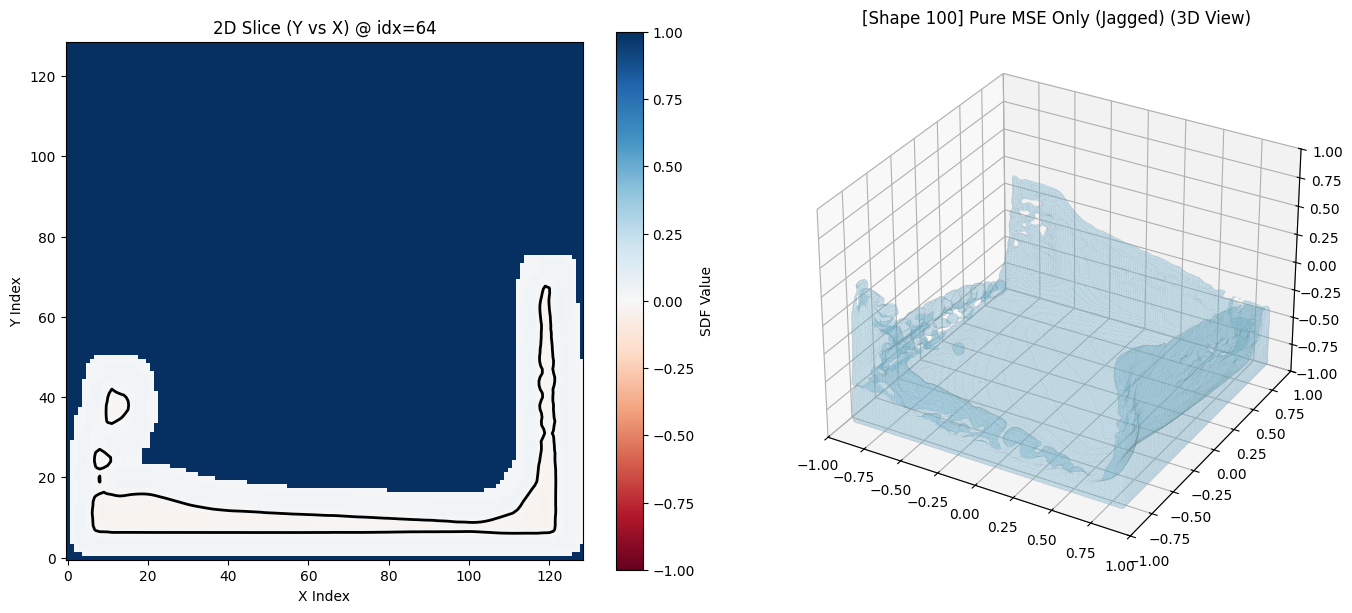

In [334]:
# ==========================================
# 🎯 [추가 실험] 특정 데이터 추론 및 비교
# ==========================================
# 🚨 여기서 원하는 데이터의 인덱스 번호만 바꾸면 끝입니다! (예: 1, 9, 10)
target_idx = 100

# 0을 채워서 자동으로 3자리 문자열로 만듭니다. (예: 1 -> "001", 15 -> "015")
shape_name = f"{target_idx:03d}" 

print("\n" + "="*55)
print(f">> 🎯 특정 테스트 데이터(Shape {shape_name}) 추론 시작")
print("="*55)

# 1. 지정된 타겟 & 특징 그리드 로드 (전처리 완전 생략!)
# 파일 경로가 자동으로 세팅됩니다.
sdf_path = f"dataset6/sdf_grid_{shape_name}.npy"
mc_path = f"dataset6/mc_grid_{shape_name}.npy"

target_sdf = np.load(sdf_path)
m_c_grid_np = np.load(mc_path)

# 텐서 변환
m_c_grid_tensor = torch.tensor(m_c_grid_np, dtype=torch.float32)

# 2. [Poly 모드] 이미 학습된 Poly 모델로 초고속 추론
print(f">> Poly 모델(정규화 ON)로 Shape {shape_name} 추론 중...")
pred_sdf_poly = reconstructor_poly.inference(m_c_grid_tensor, patch_size=8, batch_size=2048)

# 3. [MSE 모드] 이미 학습된 MSE 모델로 초고속 추론
print(f">> MSE 모델(정규화 OFF)로 Shape {shape_name} 추론 중...")
pred_sdf_mse = reconstructor_mse.inference(m_c_grid_tensor, patch_size=8, batch_size=2048)

# ==========================================
# 📊 결과 시각화 및 비교
# ==========================================
print(f"\n=== [Step 7] Shape {shape_name} 결과물 시각화 (Unseen Data Test) ===")

# 1. 정답지 (진짜 모습)
visualize_simulation(
    sdf_grid=target_sdf, 
    domain_size=config.domain_size, 
    title=f"[Shape {shape_name}] Ground Truth"
)

# 2. 논문 세팅 결과 (정규화가 들어간 매끄러운 예측 결과)
visualize_simulation(
    sdf_grid=pred_sdf_poly.cpu().numpy(), 
    domain_size=config.domain_size, 
    title=f"[Shape {shape_name}] Polynomial + MSE (Smooth)"
)

# 3. 정규화 끈 결과 (정규화가 없을 때의 쭈글쭈글한 예측 결과)
visualize_simulation(
    sdf_grid=pred_sdf_mse.cpu().numpy(), 
    domain_size=config.domain_size, 
    title=f"[Shape {shape_name}] Pure MSE Only (Jagged)"
)


>> 🎯 특정 테스트 데이터(Shape 100) 고해상도(2배) 추론 시작
>> Poly 모델(정규화 ON)로 Shape 100 고해상도 뻥튀기 중...
🚀 [Staggered Reconstruction] 해상도(2배) 레벨셋 복원
 ⏳ 엇갈린 그리드 추론 중... 조합: a=0, b=0, c=0 (Offset: (0.0, 0.0, 0.0))
   ✂️ [Pruning ON] 2097152개 중 622507개 노드 연산 (29.7%)
 ⏳ 엇갈린 그리드 추론 중... 조합: a=0, b=0, c=1 (Offset: (0.0, 0.0, 0.007874015748031496))
   ✂️ [Pruning ON] 2097152개 중 618268개 노드 연산 (29.5%)
 ⏳ 엇갈린 그리드 추론 중... 조합: a=0, b=1, c=0 (Offset: (0.0, 0.007874015748031496, 0.0))
   ✂️ [Pruning ON] 2097152개 중 614546개 노드 연산 (29.3%)
 ⏳ 엇갈린 그리드 추론 중... 조합: a=0, b=1, c=1 (Offset: (0.0, 0.007874015748031496, 0.007874015748031496))
   ✂️ [Pruning ON] 2097152개 중 610989개 노드 연산 (29.1%)
 ⏳ 엇갈린 그리드 추론 중... 조합: a=1, b=0, c=0 (Offset: (0.007874015748031496, 0.0, 0.0))
   ✂️ [Pruning ON] 2097152개 중 618082개 노드 연산 (29.5%)
 ⏳ 엇갈린 그리드 추론 중... 조합: a=1, b=0, c=1 (Offset: (0.007874015748031496, 0.0, 0.007874015748031496))
   ✂️ [Pruning ON] 2097152개 중 614075개 노드 연산 (29.3%)
 ⏳ 엇갈린 그리드 추론 중... 조합: a=1, b=1, c=0 (Offset: (0.00787401574

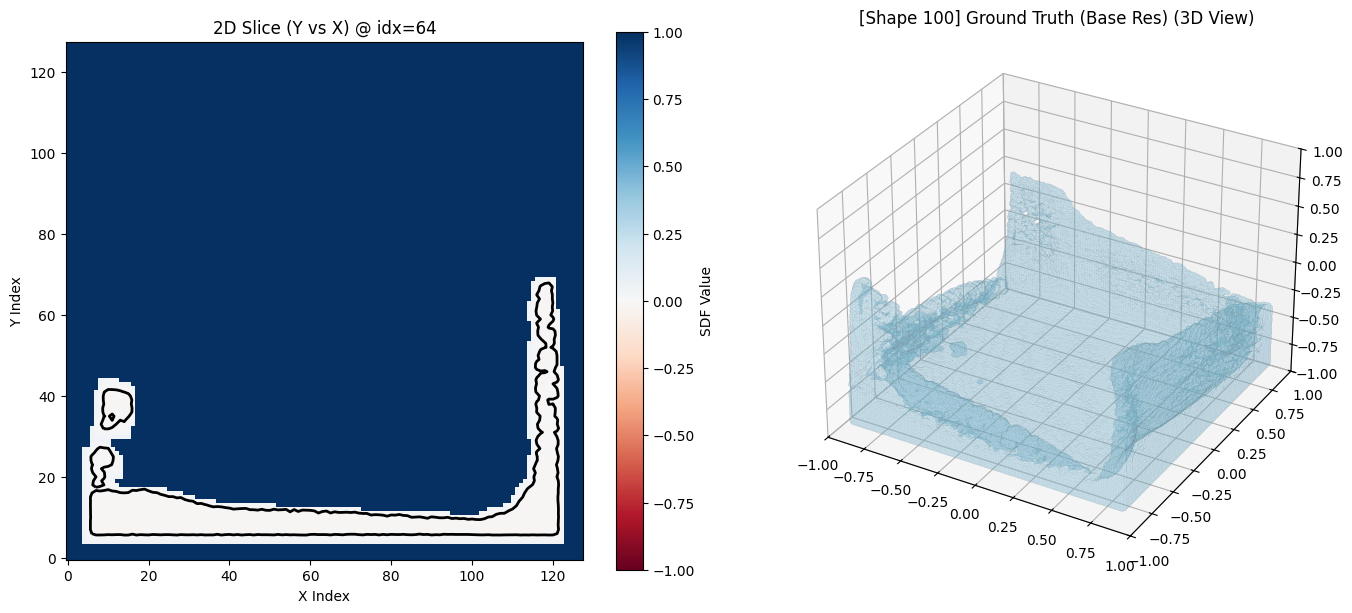

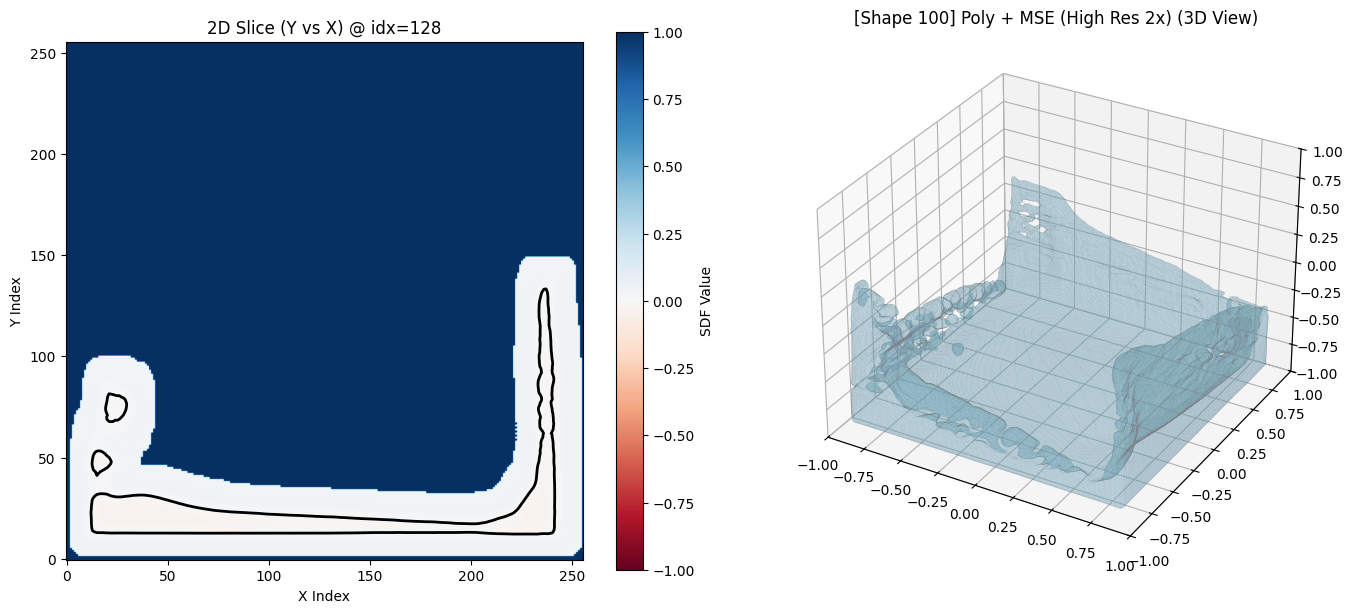

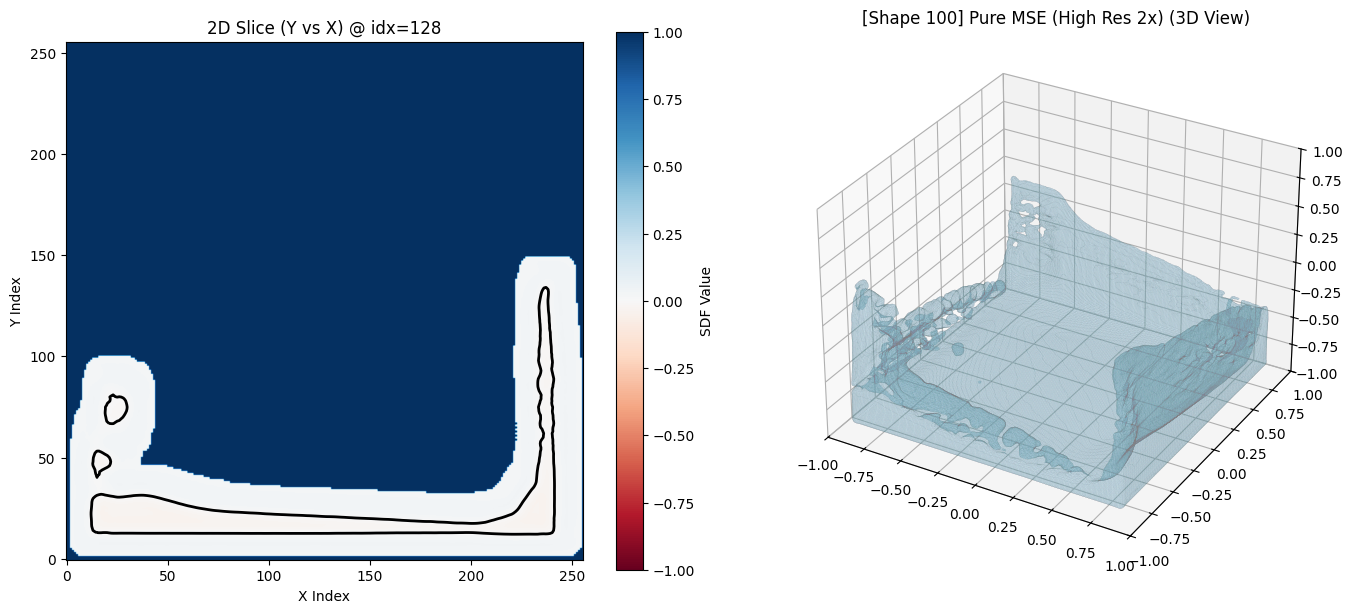

In [281]:
# ==========================================
# 🎯 [추가 실험] 특정 데이터 고해상도(Staggered) 추론 및 비교
# ==========================================
# 🚨 여기서 원하는 데이터의 인덱스 번호만 바꾸면 끝입니다! (예: 1, 9, 10)
target_idx = 100

# 0을 채워서 자동으로 3자리 문자열로 만듭니다. (예: 1 -> "001", 15 -> "015")
shape_name = f"{target_idx:03d}" 

print("\n" + "="*55)
print(f">> 🎯 특정 테스트 데이터(Shape {shape_name}) 고해상도(2배) 추론 시작")
print("="*55)

# 1. 원본 파티클 데이터 & 정답 타겟 그리드 로드
# 🚨 핵심 변경: 이전처럼 mc_grid를 쓰지 않고, 최근 생성한 dataset4의 particles를 불러옵니다!
sdf_path = f"dataset6/sdf_grid_{shape_name}.npy"
particles_path = f"dataset6/particles_{shape_name}.npy"

target_sdf = np.load(sdf_path)          # (N, N, N) 기본 해상도 정답지
particles_np = np.load(particles_path)  # 원본 파티클 좌표

# 파티클을 텐서로 변환하여 GPU로 전송
particles_tensor = torch.tensor(particles_np, dtype=torch.float32, device=device)

# 2. [Poly 모드] 엇갈린 그리드(Staggered) 다중 추론 
print(f">> Poly 모델(정규화 ON)로 Shape {shape_name} 고해상도 뻥튀기 중...")
start_time = time.time()
pred_sdf_poly_high_res = reconstructor_poly.staggered_inference(
    particles_tensor, patch_size=8, batch_size=2048
)
print(f"   -> ⏱️ 소요 시간: {time.time() - start_time:.1f}초")

# 3. [MSE 모드] 엇갈린 그리드(Staggered) 다중 추론
print(f">> MSE 모델(정규화 OFF)로 Shape {shape_name} 고해상도 뻥튀기 중...")
start_time = time.time()
pred_sdf_mse_high_res = reconstructor_mse.staggered_inference(
    particles_tensor, patch_size=8, batch_size=2048
)
print(f"   -> ⏱️ 소요 시간: {time.time() - start_time:.1f}초")

# ==========================================
# 📊 결과 시각화 및 비교
# ==========================================
print(f"\n=== [Step 7] Shape {shape_name} 고해상도 결과물 시각화 ===")
print("💡 참고: Ground Truth는 기본 해상도(N)이며, 예측 결과는 2배 해상도(2N)입니다.")

# 1. 정답지 (기본 해상도)
visualize_simulation(
    sdf_grid=target_sdf, 
    domain_size=config.domain_size, 
    title=f"[Shape {shape_name}] Ground Truth (Base Res)"
)

# 2. 논문 세팅 결과 (2배 해상도 + 정규화로 매우 매끄러움)
visualize_simulation(
    sdf_grid=pred_sdf_poly_high_res.cpu().numpy(), 
    domain_size=config.domain_size, 
    title=f"[Shape {shape_name}] Poly + MSE (High Res 2x)"
)

# 3. 정규화 끈 결과 (2배 해상도지만 표면이 울퉁불퉁할 수 있음)
visualize_simulation(
    sdf_grid=pred_sdf_mse_high_res.cpu().numpy(), 
    domain_size=config.domain_size, 
    title=f"[Shape {shape_name}] Pure MSE (High Res 2x)"
)

In [286]:
def load_particles_from_txt(txt_path, device='cpu'):
    """
    x y z 형태로 저장된 파티클 .txt 파일을 읽어 PyTorch 텐서로 반환합니다.
    (축 방향 수정 및 -1~1 스케일 정규화 포함)
    """
    import os
    import numpy as np
    import torch

    if not os.path.exists(txt_path):
        raise FileNotFoundError(f"❌ 파일을 찾을 수 없습니다: {txt_path}")
        
    print(f"📄 파티클 파일 로드 중: {txt_path}")
    
    valid_particles = []
    error_count = 0
    
    with open(txt_path, 'r') as f:
        for line_idx, line in enumerate(f):
            line = line.strip()
            if not line:
                continue
                
            parts = line.split()
            if len(parts) == 3:
                try:
                    # 1. 텍스트에서 숫자 추출
                    x = float(parts[0])
                    y = float(parts[1])
                    z = float(parts[2])
                    
                    # 🚨 [해결책 1] Y축과 Z축 스왑 (Coordinate System 교정)
                    # 기존 [x, y, z] 대신 [x, z, y] 순서로 리스트에 담습니다.
                    valid_particles.append([x, y, z])
                    
                except ValueError:
                    error_count += 1
            else:
                if error_count == 0: 
                    print(f"  ⚠️ [형식 무시됨] Line {line_idx+1}: '{line}'")
                error_count += 1

    if not valid_particles:
        raise ValueError("❌ 유효한 파티클(x y z) 데이터를 하나도 찾지 못했습니다.")
        
    particles_np = np.array(valid_particles, dtype=np.float32)
    
    # =======================================================
    # 🚨 [해결책 2] 0~1 공간을 -1~1 공간으로 뻥튀기 (Scale Remapping)
    # 공식: New_Value = (Old_Value * 2.0) - 1.0
    # 이렇게 하면 0.0은 -1.0이 되고, 0.5는 0.0(중앙)이 되며, 1.0은 1.0이 됩니다.
    # =======================================================
    print(f"🔍 변환 전 파티클 범위: Min {particles_np.min():.3f} ~ Max {particles_np.max():.3f}")
    
    particles_np = (particles_np) - 0.5
    
    print(f"🚀 변환 후 파티클 범위: Min {particles_np.min():.3f} ~ Max {particles_np.max():.3f} (그리드 최적화 완료!)")
    # =======================================================

    print(f"✅ 로드 완료! 정상 파티클: {particles_np.shape[0]:,}개 (건너뛴 줄: {error_count}개)")
    
    # GPU 텐서로 변환하여 반환
    particles_tensor = torch.tensor(particles_np, dtype=torch.float32, device=device)
    return particles_tensor

📄 파티클 파일 로드 중: frame_094.txt
🔍 변환 전 파티클 범위: Min 0.004 ~ Max 0.994
🚀 변환 후 파티클 범위: Min -0.496 ~ Max 0.494 (그리드 최적화 완료!)
✅ 로드 완료! 정상 파티클: 358,770개 (건너뛴 줄: 0개)
✅ 기하학적 특징 추출 완료
   - Grid Shape: (128, 128, 128)
   - m_c 통계: Min=0.0000, Max=1.3595


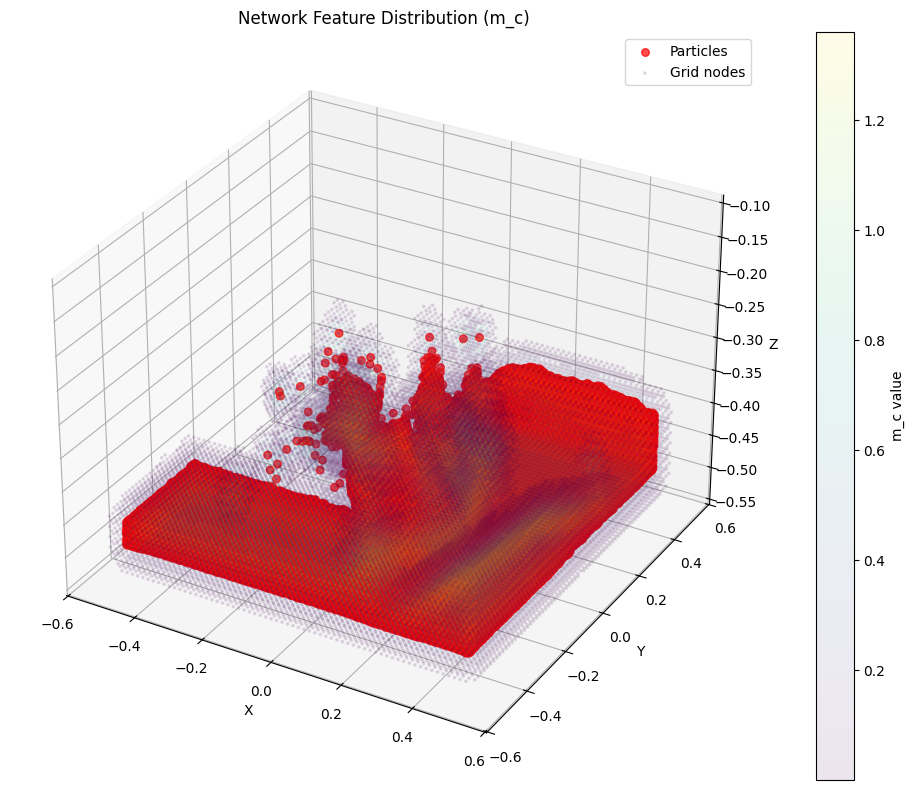

In [174]:
# 🚨 읽어올 파티클 텍스트 파일 경로
txt_particle_path = "frame_094.txt"
particles_tensor = load_particles_from_txt(txt_particle_path, device=device)

# 파티클 위치 기반으로 동적 그리드 변환 
grid_nodes, m_c, grid_shape = feature_constructor(particles_tensor)
m_c_grid = m_c.reshape(grid_shape).cpu().numpy()

print(f"✅ 기하학적 특징 추출 완료")
print(f"   - Grid Shape: {grid_shape}")
print(f"   - m_c 통계: Min={m_c.min():.4f}, Max={m_c.max():.4f}")

# ==========================================
# Phase 4: 데이터 저장 (.npy)
# ==========================================
# print("\n[Phase 4] 💾 생성된 데이터를 .npy 형식으로 저장 중...")

# # 출력 폴더 생성 (선택 사항, 깔끔한 관리를 위해)
save_dir = "./"
os.makedirs(save_dir, exist_ok=True)

# # 텐서로 남아있는 grid_nodes를 numpy로 변환
grid_nodes_np = grid_nodes.cpu().numpy() if isinstance(grid_nodes, torch.Tensor) else grid_nodes


# 4-2. 파티클 분포와 네트워크의 m_c 추출 결과 뷰어
visualize_particles_and_features(
    particles=particles_tensor.cpu(),
    grid_nodes=grid_nodes.cpu(),
    m_c_grid=m_c_grid,
    title="Network Feature Distribution (m_c)"
)



>> 🎯 외부 파티클 데이터(frame_094.txt) 고해상도(2배) 추론 시작
📄 파티클 파일 로드 중: frame_094.txt
🔍 변환 전 파티클 범위: Min 0.004 ~ Max 0.994
🚀 변환 후 파티클 범위: Min -0.496 ~ Max 0.494 (그리드 최적화 완료!)
✅ 로드 완료! 정상 파티클: 358,770개 (건너뛴 줄: 0개)
   -> ⏱️ 변환 소요 시간: 0.5초

>> Poly 모델(정규화 ON)로 고해상도 뻥튀기 중...
🚀 [Staggered Reconstruction] 해상도(2배) 레벨셋 복원
 ⏳ 엇갈린 그리드 추론 중... 조합: a=0, b=0, c=0 (Offset: (0.0, 0.0, 0.0))
   ✂️ [Pruning ON] 2097152개 중 93266개 노드 연산 (4.4%)
 ⏳ 엇갈린 그리드 추론 중... 조합: a=0, b=0, c=1 (Offset: (0.0, 0.0, 0.007874015748031496))
   ✂️ [Pruning ON] 2097152개 중 93674개 노드 연산 (4.5%)
 ⏳ 엇갈린 그리드 추론 중... 조합: a=0, b=1, c=0 (Offset: (0.0, 0.007874015748031496, 0.0))
   ✂️ [Pruning ON] 2097152개 중 94994개 노드 연산 (4.5%)
 ⏳ 엇갈린 그리드 추론 중... 조합: a=0, b=1, c=1 (Offset: (0.0, 0.007874015748031496, 0.007874015748031496))
   ✂️ [Pruning ON] 2097152개 중 95460개 노드 연산 (4.6%)
 ⏳ 엇갈린 그리드 추론 중... 조합: a=1, b=0, c=0 (Offset: (0.007874015748031496, 0.0, 0.0))
   ✂️ [Pruning ON] 2097152개 중 93797개 노드 연산 (4.5%)
 ⏳ 엇갈린 그리드 추론 중... 조합: a=1, b=0, c=1 (Offset

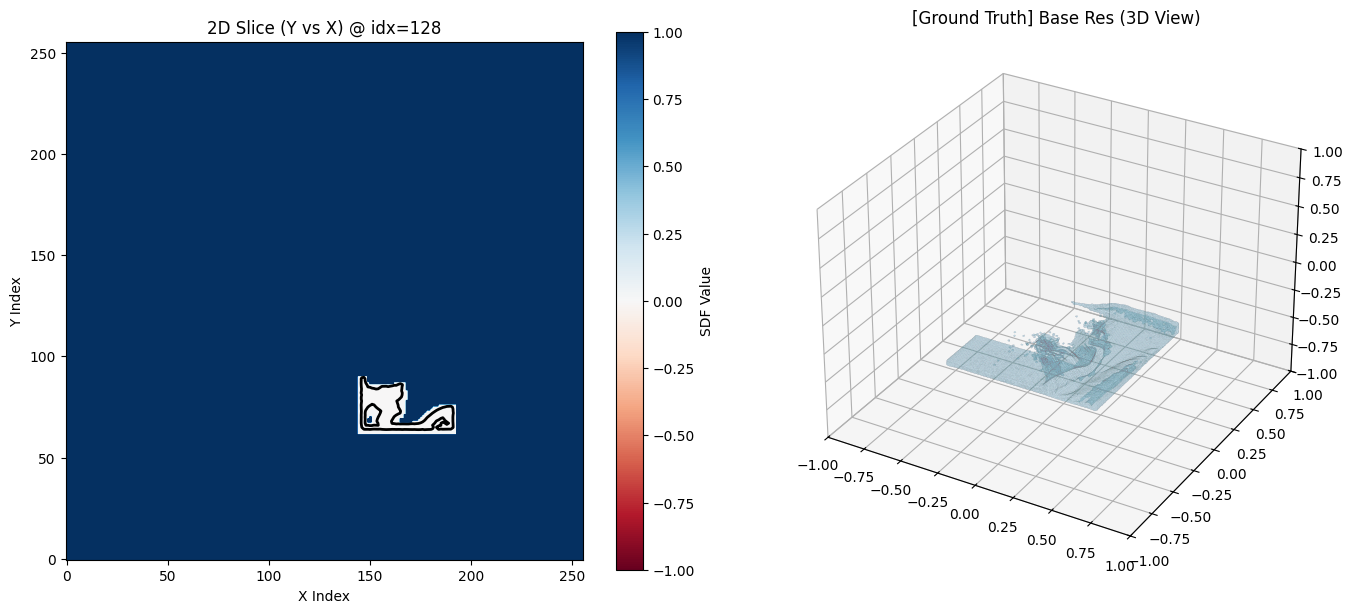

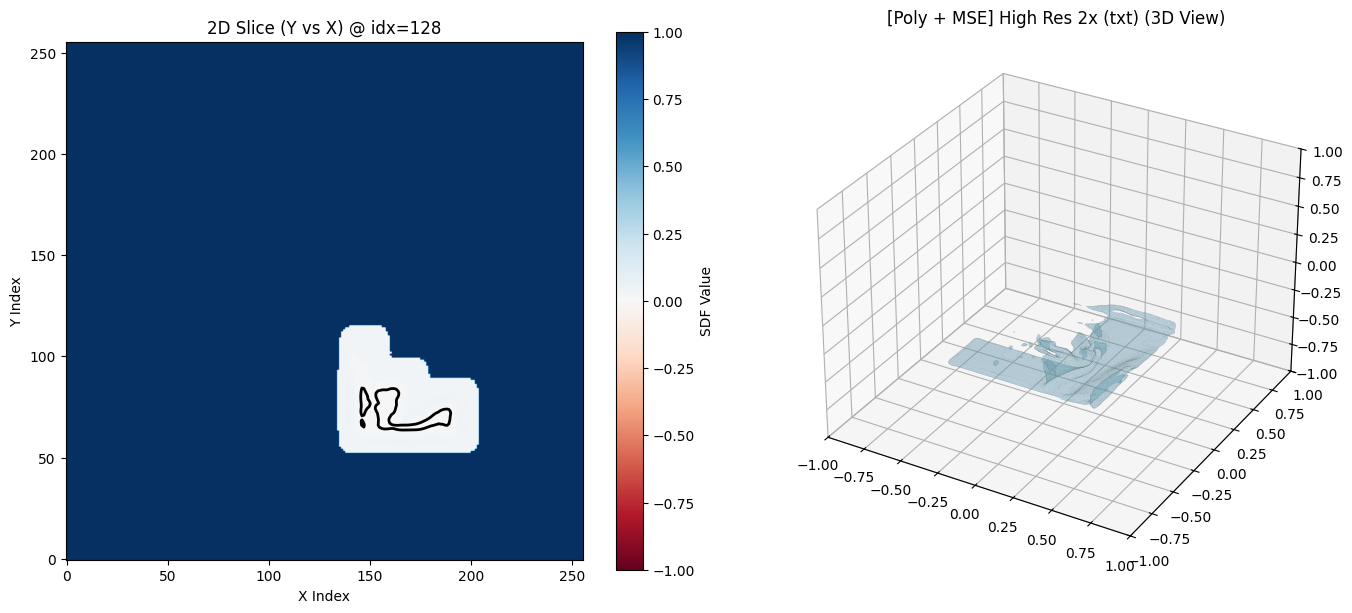

In [ ]:
# 만약 정답지(GT) SDF가 있다면 경로를 적고, 없다면 None으로 두세요.
gt_sdf_path = None # 예: "dataset5/sdf_grid_001.npy"
txt_particle_path = "frame_094.txt"
print("\n" + "="*55)
print(f">> 🎯 외부 파티클 데이터({txt_particle_path}) 고해상도(2배) 추론 시작")
print("="*55)

# 1. 텍스트 파티클 데이터 텐서로 로드
particles_tensor = load_particles_from_txt(txt_particle_path, device=device)

# 정답지 로드 (있는 경우에만)
target_sdf = None
if gt_sdf_path and os.path.exists(gt_sdf_path):
    target_sdf = np.load(gt_sdf_path)
    print("📊 정답지(Ground Truth) SDF를 로드했습니다.")
else:
    # print("💡 정답지(Ground Truth) 없이 모델 예측만 수행합니다.")
    # GPU 텐서일 수 있으므로 CPU로 내린 뒤 Numpy 배열로 변환
    particles_np = particles_tensor.cpu().numpy()

    # 2. 고해상도(2배) 해상도 계산
    # 기존 추론 코드에서 patch_size=8 및 Staggered 방식을 통해 2배 뻥튀기 하므로, GT도 2배로 맞춥니다.
    high_res = config.resolution * 2  

    # 3. Taichi 커널을 이용해 파티클 -> SDF 변환
    # (클래스 이름이 TaichiFluidSolver가 아니라면 알맞게 수정해주세요)
    start_time = time.time()
    target_sdf = TaichiFluidSolver.convert_particles_to_sdf(
        particles_np=particles_np,
        res=high_res,
        domain_size=config.domain_size,
        radius_ratio = 1.25  # 🔥 물기둥이 뚱뚱해지지 않도록 0.5 수준으로 날렵하게 세팅
    )
    print(f"   -> ⏱️ 변환 소요 시간: {time.time() - start_time:.1f}초")

# 2. [Poly 모드] 엇갈린 그리드(Staggered) 다중 추론 
print("\n>> Poly 모델(정규화 ON)로 고해상도 뻥튀기 중...")
start_time = time.time()
pred_sdf_poly_high_res = reconstructor_poly.staggered_inference(
    particles_tensor, patch_size=8, batch_size=2048
)
print(f"   -> ⏱️ 소요 시간: {time.time() - start_time:.1f}초")

# 3. [MSE 모드] 엇갈린 그리드(Staggered) 다중 추론
# print("\n>> MSE 모델(정규화 OFF)로 고해상도 뻥튀기 중...")
# start_time = time.time()
# pred_sdf_mse_high_res = reconstructor_mse.staggered_inference(
#     particles_tensor, patch_size=8, batch_size=2048
# )
# print(f"   -> ⏱️ 소요 시간: {time.time() - start_time:.1f}초")

# ==========================================
# 📊 결과 시각화 및 비교
# ==========================================
print(f"\n=== [Step 3] 예측 결과물 시각화 ===")

# 1. 정답지 (존재할 때만 렌더링)
if target_sdf is not None:
    visualize_simulation(
        sdf_grid=target_sdf, 
        domain_size=config.domain_size, 
        title="[Ground Truth] Base Res"
    )

# 2. 논문 세팅 결과 (2배 해상도 + 정규화로 매우 매끄러움)
visualize_simulation(
    sdf_grid=pred_sdf_poly_high_res.cpu().numpy(), 
    domain_size=config.domain_size, 
    title="[Poly + MSE] High Res 2x (txt)"
)

# 3. 정규화 끈 결과 (2배 해상도지만 표면이 울퉁불퉁할 수 있음)
# visualize_simulation(
#     sdf_grid=pred_sdf_mse_high_res.cpu().numpy(), 
#     domain_size=config.domain_size, 
#     title="[Pure MSE] High Res 2x (txt)"
# )

### 3.4 3D CNN 네트워크를 통한 SDF 값 추론

## 4. SDF 값 시각화 (최종 결과)

4.2 obj로 저장(mc 알고리즘)

In [ ]:
from modules.visualizer import visualize_npy
from modules.visualizer import save_mesh_as_obj # 시각화용
from modules.visualizer import visualize_simulation
import numpy as np
from modules.visualizer import view_obj_and_particles_interactive

In [329]:
save_mesh_as_obj(target_sdf, filename="gt.obj")
save_mesh_as_obj(pred_sdf_poly.cpu().numpy(), filename="train_shape.obj")
save_mesh_as_obj(pred_sdf_mse.cpu().numpy(), filename="test_shape.obj")

✅ 메쉬 저장 완료: gt.obj (Vertices: 54359)
✅ 메쉬 저장 완료: train_shape.obj (Vertices: 17592)
✅ 메쉬 저장 완료: test_shape.obj (Vertices: 14237)


In [299]:
from modules.visualizer import save_mesh_as_obj # 시각화용
save_mesh_as_obj(target_sdf, filename="gt_high.obj")
save_mesh_as_obj(pred_sdf_poly_high_res.cpu().numpy(), filename="pred_sdf_poly_high_res.obj")
# save_mesh_as_obj(pred_sdf_mse_high_res.cpu().numpy(), filename="pred_sdf_mse_high_res.obj")

✅ 메쉬 저장 완료: gt_high.obj (Vertices: 54359)
✅ 메쉬 저장 완료: pred_sdf_poly_high_res.obj (Vertices: 35907)


npy 파일 이용한 sdf 시각화

In [ ]:
# 2. 데이터 시각화 (Phase 2)
print("\n--- Phase 2: 시각화 및 저장 ---")

# SDF 파일 확인
visualize_npy("sdf_grid_64.npy")

# 파티클 파일 확인
visualize_npy("particles.npy")


변수(객체) 이용한 시각화(런타임에 있는 메모리)

In [ ]:
# SDF만 보기 (기존 plot_slice + 3D)
visualize_simulation(sdf_grid=sdf_grid)

# 파티클까지 겹쳐서 보기 (기존 plot_particles_and_sdf_slice + 3D)
visualize_simulation(sdf_grid=sdf_grid, particles=particles)

obj 인터랙티브 뷰어

In [330]:
save_mesh_as_obj(target_sdf, filename="gt_high.obj")
# OBJ 파일 인터랙티브 뷰어
view_obj_interactive("gt_high.obj")

✅ 메쉬 저장 완료: gt_high.obj (Vertices: 54359)
🖥️ 3D 뷰어 실행 중: gt_high.obj ...
✅ 뷰어 종료됨.


In [331]:
# 1. 파일에서 넘파이 배열 읽어오기
# particles_np = np.load("frame_001.npy")

particles_np = load_particles_from_txt("frame_094.txt")
# 🚨 변경된 부분: x, y, z에 각각 0.5 오프셋 추가
particles_np += 0.5

# 2. 뷰어에 메쉬와 파티클 배열 함께 전달하기
view_obj_and_particles_interactive("gt_high.obj", particles_np, 128, 1.0)

📄 파티클 파일 로드 중: frame_094.txt
🔍 변환 전 파티클 범위: Min 0.004 ~ Max 0.994
🚀 변환 후 파티클 범위: Min -0.496 ~ Max 0.494 (그리드 최적화 완료!)
✅ 로드 완료! 정상 파티클: 358,770개 (건너뛴 줄: 0개)
🖥️ 3D 뷰어 실행 중 (실시간 좌표 변환 적용): gt_high.obj ...
✅ 파티클 358,770개 정렬 완료.
🔍 메쉬 범위 확인: -0.00 ~ 1.01


In [332]:
# OBJ 파일 인터랙티브 뷰어
view_obj_interactive("train_shape.obj")

🖥️ 3D 뷰어 실행 중: train_shape.obj ...
✅ 뷰어 종료됨.


In [333]:
# OBJ 파일 인터랙티브 뷰어
view_obj_interactive("test_shape.obj")

🖥️ 3D 뷰어 실행 중: test_shape.obj ...
✅ 뷰어 종료됨.


In [300]:
# OBJ 파일 인터랙티브 뷰어
view_obj_interactive("pred_sdf_poly_high_res.obj")

🖥️ 3D 뷰어 실행 중: pred_sdf_poly_high_res.obj ...
✅ 뷰어 종료됨.


In [285]:
# 1. 파일에서 넘파이 배열 읽어오기
# particles_np = np.load("frame_001.npy")

particles_np = load_particles_from_txt("frame_094.txt")
# 🚨 변경된 부분: x, y, z에 각각 0.5 오프셋 추가
particles_np += 0.5

# 2. 뷰어에 메쉬와 파티클 배열 함께 전달하기
view_obj_and_particles_interactive("pred_sdf_poly_high_res.obj", particles_np, 128, 1.0)

📄 파티클 파일 로드 중: frame_094.txt
🔍 변환 전 파티클 범위: Min 0.004 ~ Max 0.994
🚀 변환 후 파티클 범위: Min -0.496 ~ Max 0.494 (그리드 최적화 완료!)
✅ 로드 완료! 정상 파티클: 358,770개 (건너뛴 줄: 0개)
🖥️ 3D 뷰어 실행 중 (실시간 좌표 변환 적용): pred_sdf_poly_high_res.obj ...
✅ 파티클 358,770개 정렬 완료.
🔍 메쉬 범위 확인: -0.41 ~ 1.40
